# Halden Marine Systems — Generative & Operator-Learning Scouting Study

Three toy models on a single free GPU:
1. DDPM-style diffusion on a 2D checkerboard
2. Flow matching / rectified flow on the same checkerboard
3. 1D Fourier Neural Operator trained on our own finite-difference Burgers solver

All reusable code lives in the `halden/` package; this notebook runs the experiments.

In [1]:
# --- Get the code (Colab) ----------------------------------------------------
# Clones the repo on first run, pulls the latest commit on later runs, then cd's into it
# so `import halden` works. Does nothing when run locally.
# Runtime > Change runtime type > GPU before running, so QUICK mode switches off.
import os, sys

REPO_URL = "https://github.com/nmilleson/csp-cst627-week4.git"
REPO_DIR = "/content/csp-cst627-week4"

if "google.colab" in sys.modules:
    if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
        !git clone {REPO_URL} {REPO_DIR}
    else:
        !git -C {REPO_DIR} pull --ff-only
    %cd {REPO_DIR}
    !git log --oneline -1

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 1.83 KiB | 623.00 KiB/s, done.
From https://github.com/nmilleson/csp-cst627-week4
   3e11ebe..a60959e  main       -> origin/main
Updating 3e11ebe..a60959e
Fast-forward
 halden_scouting.ipynb | 56 ++++++++++++++++++++++++++++++++++++++++++++++++++-
 1 file changed, 55 insertions(+), 1 deletion(-)
/content/csp-cst627-week4
a60959e (HEAD -> main, origin/main, origin/HEAD) Add rectified-flow vs DDPM sample gallery to head-to-head section


In [2]:
# --- Setup -------------------------------------------------------------------
import sys, time, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

# QUICK shrinks training budgets so the notebook can be smoke-tested on CPU.
QUICK = DEVICE == "cpu"
RESULTS = {}            # every measured number for the final decision walkthrough
Path("results").mkdir(exist_ok=True); Path("checkpoints").mkdir(exist_ok=True)

torch 2.11.0+cu130 | device: cuda | Tesla T4


## Part 0 — Data generation

### 0.1 Checkerboard (shared by diffusion and flow matching)

Exact sampling from the 8 black cells of a 4×4 board on $[-2, 2]^2$. A held-out reference set is kept for sample-quality metrics. `support_fraction` (fraction of samples on a black cell) is our first, very interpretable quality score: perfect = 1.0, a Gaussian blob ≈ 0.43.

train (100000, 2) ref (20000, 2)
mean [-0.001 -0.003] std [1.153 1.155]
support fraction (train): 1.0
support fraction (moment-matched Gaussian baseline): 0.424


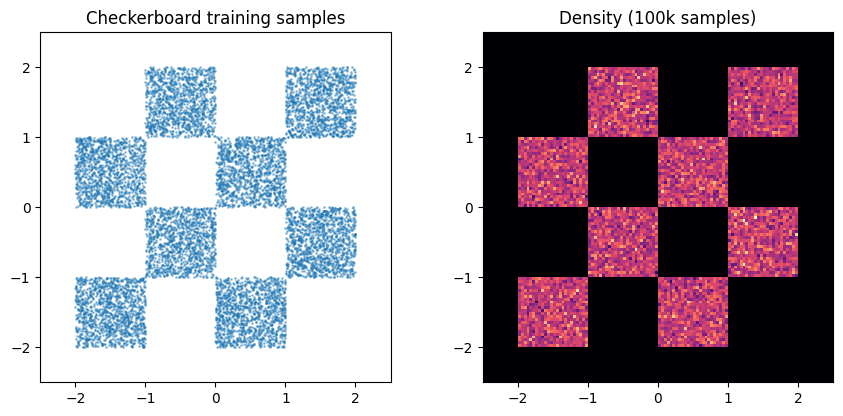

In [3]:
from halden.data2d import make_checkerboard_splits, support_fraction

X_train, X_ref = make_checkerboard_splits(n_train=100_000, n_ref=20_000, seed=0)
print("train", X_train.shape, "ref", X_ref.shape)
print("mean", X_train.mean(0).round(3), "std", X_train.std(0).round(3))
print("support fraction (train):", support_fraction(X_train))
gauss = np.random.default_rng(1).standard_normal((20_000, 2)) * X_train.std()
print("support fraction (moment-matched Gaussian baseline):", round(support_fraction(gauss), 3))

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].scatter(*X_train[:10_000].T, s=1, alpha=0.4)
ax[0].set_title("Checkerboard training samples")
ax[1].hist2d(*X_train.T, bins=120, range=[[-2.5, 2.5]] * 2, cmap="magma")
ax[1].set_title("Density (100k samples)")
for a in ax: a.set_aspect("equal"); a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

### 0.2 Burgers' equation (for the neural operator)

$u_t + (u^2/2)_x =
u u_{xx}$ on $[0,1)$ periodic, $
u = 0.005$, $T = 0.5$. Operator to learn: $u(\cdot,0) \mapsto u(\cdot,T)$.

Solver (`halden/burgers.py`): MUSCL-minmod + Rusanov flux for convection (SSP-RK2), central-difference Laplacian for diffusion integrated exactly per half-step (Strang splitting). Initial conditions are periodic Gaussian random fields.

First we **validate the solver** against the exact Cole–Hopf solution, so later operator errors can't be blamed on bad data.

     N  rel L2 vs exact  ratio
   128         7.92e-03 
   256         2.22e-03   3.56
   512         5.84e-04   3.81
  1024         1.49e-04   3.91
  2048         3.77e-05   3.96


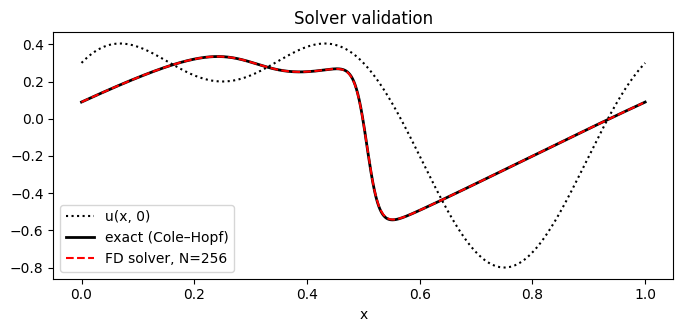

In [4]:
from halden.burgers import solve_burgers, cole_hopf_reference

NU, T_FINAL = 0.005, 0.5
f = lambda x: 0.5 * np.sin(2 * np.pi * x) + 0.3 * np.cos(4 * np.pi * x)
x_ref, u_exact = cole_hopf_reference(f, NU, T_FINAL, n_grid=8192)

print(f"{'N':>6} {'rel L2 vs exact':>16} {'ratio':>6}")
prev = None
for N in [128, 256, 512, 1024, 2048]:
    x = np.arange(N) / N
    u_num = solve_burgers(f(x)[None], NU, T_FINAL)[0]
    ref = u_exact[:: 8192 // N]
    err = np.linalg.norm(u_num - ref) / np.linalg.norm(ref)
    print(f"{N:>6} {err:>16.2e} {'' if prev is None else f'{prev / err:6.2f}'}")
    prev = err

plt.figure(figsize=(8, 3.2))
plt.plot(x_ref, f(x_ref), "k:", label="u(x, 0)")
plt.plot(x_ref, u_exact, "k", lw=2, label="exact (Cole–Hopf)")
x = np.arange(256) / 256
plt.plot(x, solve_burgers(f(x)[None], NU, T_FINAL)[0], "r--", label="FD solver, N=256")
plt.legend(); plt.title("Solver validation"); plt.xlabel("x"); plt.show()

Now generate the dataset once on a **fine grid (N = 1024)** and cache it. Lower resolutions (for training, and for the resolution-mismatch failure later) come from stride-subsampling the same solutions.

dataset ready in 0.1s: (1200, 1024) (1200, 1024)
train (1000, 1024) test (200, 1024)
median peak |u_x|: t=0 8.5 -> t=T 23.8  (shock steepening)


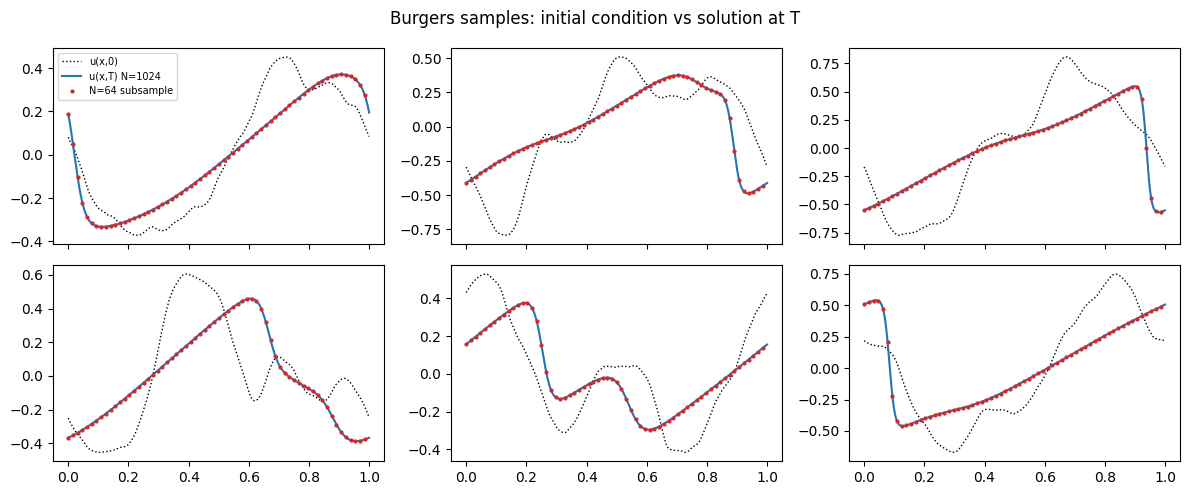

In [5]:
from halden.burgers import generate_burgers_dataset, subsample, train_test_split

t0 = time.time()
burgers = generate_burgers_dataset(n_samples=1200, n_grid=1024, nu=NU, t_final=T_FINAL,
                                   seed=0, cache_path="data/burgers_N1024.npz")
print(f"dataset ready in {time.time() - t0:.1f}s:", burgers["u0"].shape, burgers["uT"].shape)
bg_train, bg_test = train_test_split(burgers, n_train=1000)
print("train", bg_train["u0"].shape, "test", bg_test["u0"].shape)

grad0 = np.abs(np.diff(burgers["u0"], axis=1)).max(1) * 1024
gradT = np.abs(np.diff(burgers["uT"], axis=1)).max(1) * 1024
print(f"median peak |u_x|: t=0 {np.median(grad0):.1f} -> t=T {np.median(gradT):.1f}  (shock steepening)")

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
x = burgers["x"]
for i, ax in enumerate(axes.flat):
    ax.plot(x, burgers["u0"][i], "k:", lw=1, label="u(x,0)")
    ax.plot(x, burgers["uT"][i], "C0", lw=1.5, label="u(x,T) N=1024")
    ax.plot(subsample(x, 64), subsample(burgers["uT"][i], 64), "C3.", ms=4, label="N=64 subsample")
axes[0, 0].legend(fontsize=7)
plt.suptitle("Burgers samples: initial condition vs solution at T"); plt.tight_layout(); plt.show()

## Part 1 — DDPM on the checkerboard

**Forward process:** $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$, $T = 1000$, linear $\beta_t \in [10^{-4}, 0.02]$.
**Objective:** $\varepsilon$-prediction MSE. **Samplers:** ancestral DDPM (1000 network evaluations) and DDIM on strided timesteps (10–250 evaluations).

Shared with flow matching (Part 2): the `TimeMLP` backbone, the `train_generative` loop (Adam, warmup + cosine LR, EMA 0.999, batch 2048), and the metrics.

### 1.1 Noise schedules and the forward process
For 2D data the linear schedule already drives $\bar\alpha_T$ to ~4e-5, so $x_T$ is effectively $\mathcal N(0, I)$, which is what the sampler assumes. Cosine is shown for reference; it keeps more signal at mid-range $t$.

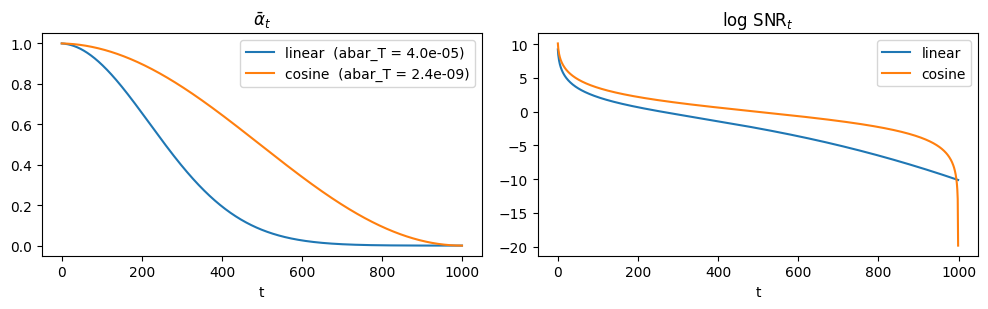

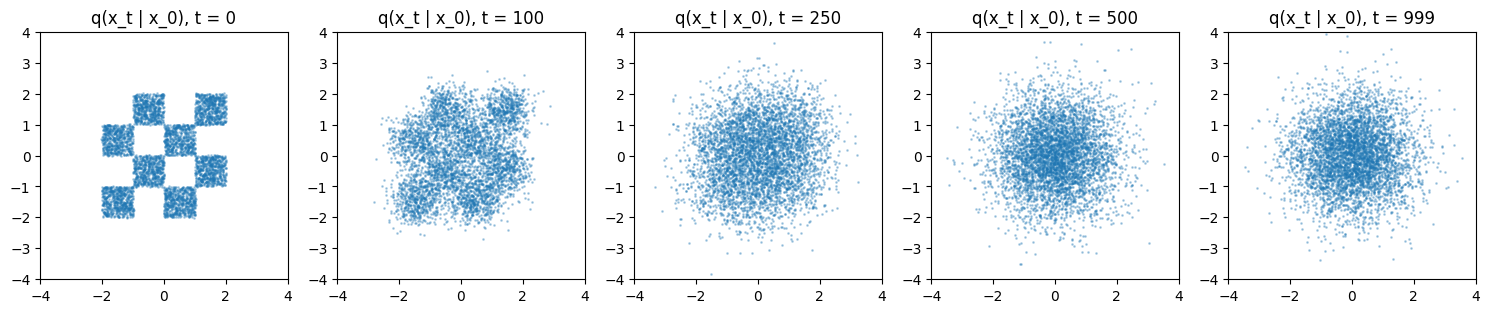

In [6]:
from halden.ddpm import make_schedule, q_sample, make_ddpm_loss, ddpm_sample, ddim_sample

SCHED = make_schedule("linear", T=1000)
cosine = make_schedule("cosine", T=1000)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for s in (SCHED, cosine):
    ax[0].plot(s.alpha_bars.numpy(), label=f"{s.name}  (abar_T = {s.alpha_bars[-1]:.1e})")
    ax[1].plot(s.log_snr().numpy(), label=s.name)
ax[0].set_title(r"$\bar\alpha_t$"); ax[1].set_title(r"log SNR$_t$"); ax[0].legend(); ax[1].legend()
for a in ax: a.set_xlabel("t")
plt.tight_layout(); plt.show()

x0 = torch.as_tensor(X_train[:5000])
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for a, t in zip(ax, [0, 100, 250, 500, 999]):
    xt = q_sample(x0, torch.full((len(x0),), t), SCHED)
    a.scatter(*xt.T, s=1, alpha=0.3); a.set_title(f"q(x_t | x_0), t = {t}")
    a.set_xlim(-4, 4); a.set_ylim(-4, 4); a.set_aspect("equal")
plt.tight_layout(); plt.show()

### 1.2 Train

TimeMLP params: 875,778
train wall-clock: 130.9s | peak VRAM: 79.4 MiB | final loss 0.2653


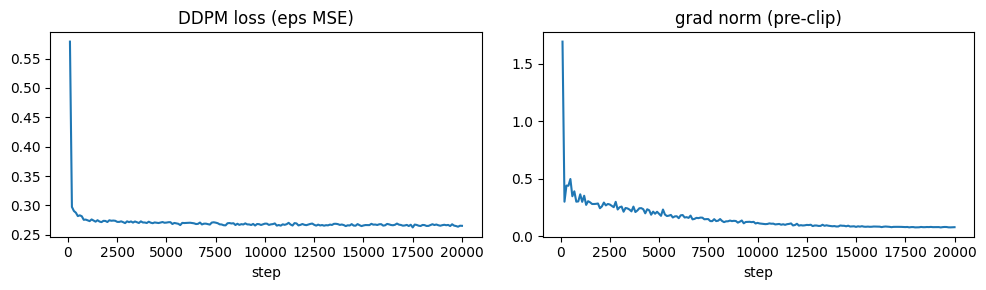

In [7]:
from halden.nets import TimeMLP, count_params
from halden.training import train_generative

GEN_CONFIG = dict(steps=2_000 if QUICK else 20_000, batch_size=2048, lr=1e-3, warmup=500,
                  ema_decay=0.999, log_every=100, seed=0)

ddpm_model = TimeMLP(dim=2, hidden=256, n_blocks=4)
print(f"TimeMLP params: {count_params(ddpm_model):,}")
ddpm_ema, ddpm_hist = train_generative(ddpm_model, make_ddpm_loss(SCHED), X_train,
                                       device=DEVICE, **GEN_CONFIG)
vram = ddpm_hist["peak_vram_mb"]
print(f"train wall-clock: {ddpm_hist['train_seconds']:.1f}s | peak VRAM: "
      f"{'n/a (CPU)' if vram is None else f'{vram:.1f} MiB'} | final loss {ddpm_hist['loss'][-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(ddpm_hist["step"], ddpm_hist["loss"]); ax[0].set_title("DDPM loss (eps MSE)")
ax[1].plot(ddpm_hist["step"], ddpm_hist["grad_norm"]); ax[1].set_title("grad norm (pre-clip)")
for a in ax: a.set_xlabel("step")
plt.tight_layout(); plt.show()

### 1.3 Ancestral sampling (1000 steps): quality, latency, VRAM

`clip_x0` clips the model's implied $\hat x_0$ to the data range at each step. It matters for $\varepsilon$-prediction: at $t \approx T$, $\hat x_0 = (x_t - \sqrt{1-\bar\alpha_t}\hat\varepsilon)/\sqrt{\bar\alpha_t}$ multiplies any $\hat\varepsilon$ error by $1/\sqrt{\bar\alpha_T} \approx 157$, and a small fraction of samples are thrown far off the board. We report both. Note that clipping requires knowing the data bounds.

metric floor (fresh true samples vs ref): {'support_fraction': 1.0, 'swd': 0.0164, 'mmd': 0.0001, 'nonfinite_fraction': 0.0}
clip_x0=None: support_fraction 0.9792 | swd 0.0151 | mmd -0.0002 | max|x| 2.1 | 19.75s for 20000 samples
clip_x0=2.0: support_fraction 0.9837 | swd 0.0151 | mmd -0.0002 | max|x| 2.0 | 19.92s for 20000 samples


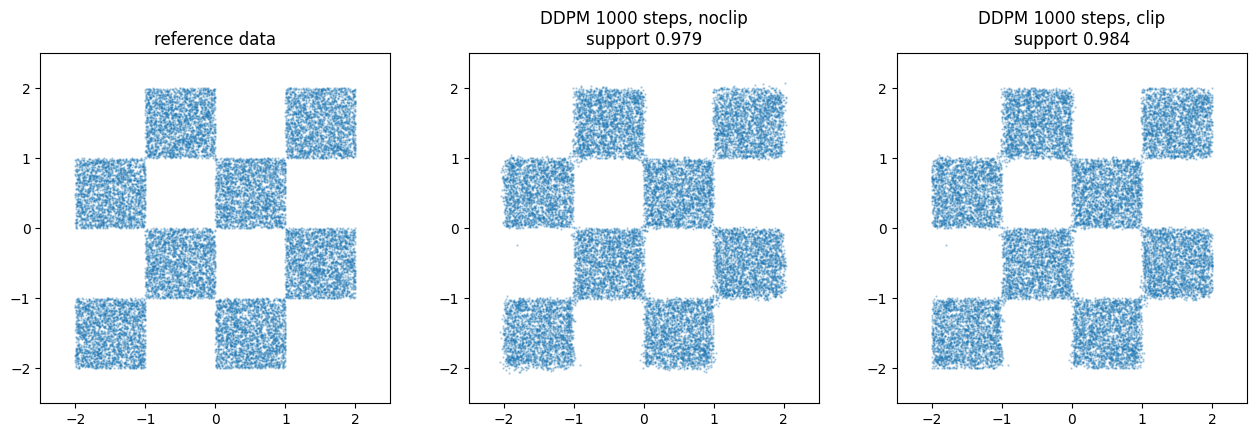

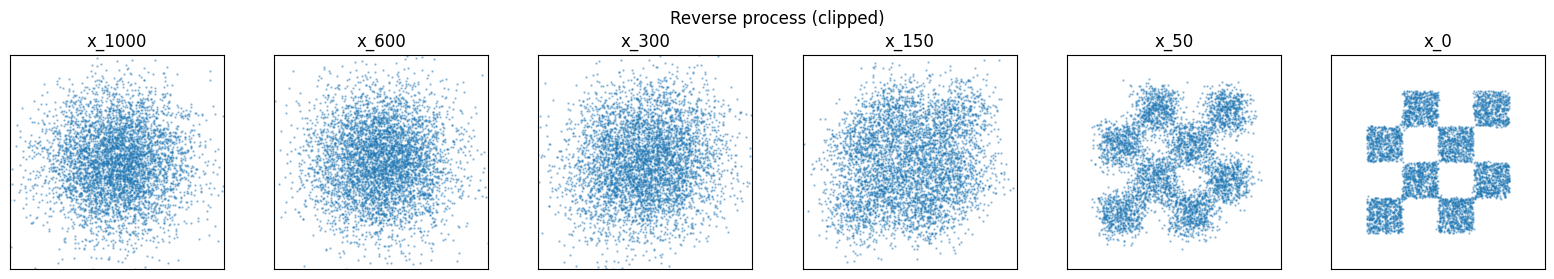

In [8]:
from halden.metrics import evaluate_samples, metric_floor, measure

N_EVAL = len(X_ref)                      # 20k samples, same size as the reference set
FLOOR = metric_floor(X_ref)
print("metric floor (fresh true samples vs ref):", {k: round(v, 4) for k, v in FLOOR.items()})

def fmt(m):
    return " | ".join(f"{k} {m[k]:.4f}" for k in ("support_fraction", "swd", "mmd"))

ddpm_runs = {}
for clip in (None, 2.0):
    (x, traj), sec, peak = measure(
        lambda: ddpm_sample(ddpm_ema, SCHED, N_EVAL, device=DEVICE, seed=0, clip_x0=clip,
                            record_every=50),
        DEVICE, warmup_fn=lambda: ddpm_sample(ddpm_ema, SCHED, 16, device=DEVICE))
    x = x.cpu().numpy()
    m = evaluate_samples(x, X_ref)
    m.update(nfe=SCHED.T, latency_s=sec, peak_vram_mb=peak, max_abs=float(np.abs(x).max()))
    ddpm_runs["clip" if clip else "noclip"] = (x, traj, m)
    print(f"clip_x0={clip}: {fmt(m)} | max|x| {m['max_abs']:.1f} | {sec:.2f}s for {N_EVAL} samples")

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
ax[0].scatter(*X_ref[:N_EVAL].T, s=0.5, alpha=0.3); ax[0].set_title("reference data")
for a, key in zip(ax[1:], ("noclip", "clip")):
    a.scatter(*ddpm_runs[key][0].T, s=0.5, alpha=0.3)
    a.set_title(f"DDPM 1000 steps, {key}\nsupport {ddpm_runs[key][2]['support_fraction']:.3f}")
for a in ax: a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5); a.set_aspect("equal")
plt.tight_layout(); plt.show()

traj = ddpm_runs["clip"][1]
fig, ax = plt.subplots(1, 6, figsize=(16, 2.8))
for a, t in zip(ax, [1000, 600, 300, 150, 50, 0]):
    a.scatter(*traj[t][:5000].T, s=0.5, alpha=0.4); a.set_title(f"x_{t}")
    a.set_xlim(-3, 3); a.set_ylim(-3, 3); a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.suptitle("Reverse process (clipped)"); plt.tight_layout(); plt.show()

### 1.4 Quality vs. sampling cost (DDIM, fewer network evaluations)

Sampling latency matters for the pilot. DDIM reuses the same trained network with a strided subset of timesteps. This sweep gives the quality-vs-NFE curve we will compare against flow matching.

sampler   NFE  support     SWD      MMD  latency s
   ddim    10   0.8001  0.1576  0.02314      0.175
   ddim    25   0.9508  0.0540  0.00285      0.470
   ddim    50   0.9779  0.0280  0.00091      0.958
   ddim   100   0.9837  0.0185  0.00054      1.934
   ddim   250   0.9827  0.0168  0.00050      4.854
   ddpm  1000   0.9837  0.0151 -0.00025     19.923
  floor         1.0000  0.0164  0.00009


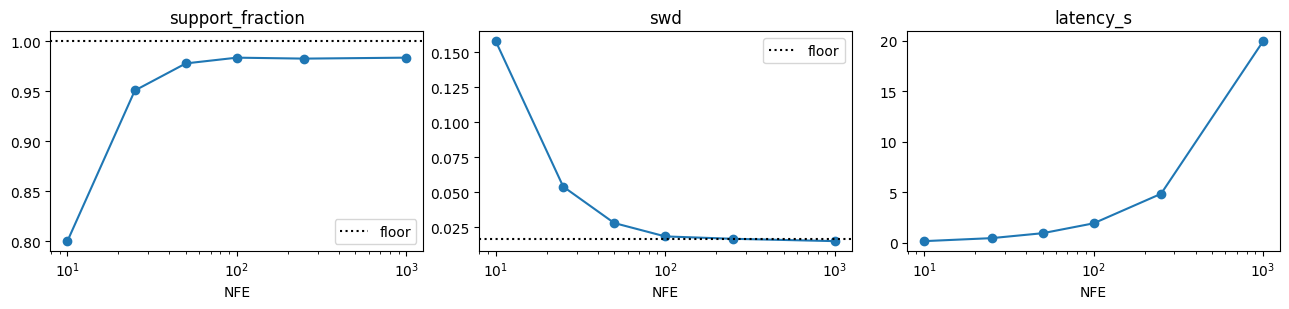

In [9]:
NFE_GRID = [10, 25, 50, 100, 250]
ddpm_sweep = []
for nfe in NFE_GRID:
    x, sec, peak = measure(
        lambda: ddim_sample(ddpm_ema, SCHED, N_EVAL, n_steps=nfe, device=DEVICE, seed=0, clip_x0=2.0),
        DEVICE, warmup_fn=lambda: ddim_sample(ddpm_ema, SCHED, 16, n_steps=nfe, device=DEVICE))
    m = evaluate_samples(x.cpu().numpy(), X_ref)
    m.update(sampler="ddim", nfe=nfe, latency_s=sec, peak_vram_mb=peak)
    ddpm_sweep.append(m)
ddpm_sweep.append(dict(ddpm_runs["clip"][2], sampler="ddpm"))

print(f"{'sampler':>7} {'NFE':>5} {'support':>8} {'SWD':>7} {'MMD':>8} {'latency s':>10}")
for m in ddpm_sweep:
    print(f"{m['sampler']:>7} {m['nfe']:>5} {m['support_fraction']:>8.4f} {m['swd']:>7.4f} "
          f"{m['mmd']:>8.5f} {m['latency_s']:>10.3f}")
print(f"{'floor':>7} {'':>5} {FLOOR['support_fraction']:>8.4f} {FLOOR['swd']:>7.4f} {FLOOR['mmd']:>8.5f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
nfes = [m["nfe"] for m in ddpm_sweep]
for a, key in zip(ax, ("support_fraction", "swd", "latency_s")):
    a.plot(nfes, [m[key] for m in ddpm_sweep], "o-")
    if key in FLOOR:
        a.axhline(FLOOR[key], color="k", ls=":", label="floor"); a.legend()
    a.set_xscale("log"); a.set_xlabel("NFE"); a.set_title(key)
plt.tight_layout(); plt.show()

In [10]:
RESULTS["ddpm"] = {
    "params": count_params(ddpm_model),
    "train_seconds": ddpm_hist["train_seconds"],
    "train_peak_vram_mb": ddpm_hist["peak_vram_mb"],
    "final_loss": ddpm_hist["loss"][-1],
    "config": ddpm_hist["config"],
    "ancestral_noclip": ddpm_runs["noclip"][2],
    "sweep": ddpm_sweep,
    "floor": FLOOR,
}
json.dump(RESULTS, open("results/results.json", "w"), indent=2)
torch.save(ddpm_ema.state_dict(), "checkpoints/ddpm_ema.pt")
print("saved results/results.json and checkpoints/ddpm_ema.pt")

saved results/results.json and checkpoints/ddpm_ema.pt


## Part 2 — Rectified flow on the same checkerboard

**Path:** $x_t = (1-t)\,z + t\,x$, with $z \sim \mathcal N(0, I)$ at $t=0$ and data at $t=1$. **Target velocity:** $v = x - z$.
**Sampling:** integrate $\dot x = v_\theta(x, t)$ from $t=0$ to $1$ with Euler or Heun (Heun = 2 network evaluations per step).

Same `TimeMLP`, same `GEN_CONFIG`, same training data, same reference set and metrics as Part 1. Only the objective and the sampler change.

1. **1-RF**: train on independent (noise, data) pairs. This is equivalent to conditional flow matching with straight paths.
2. **Reflow → 2-RF**: use 1-RF to map fresh noise to samples, then train a new model on those fixed couplings. The learned ODE gets straighter, so few-step sampling improves. Its cost (pair generation + a second training run) is counted in wall-clock.

### 2.1 Train 1-RF

1-RF train wall-clock: 126.8s | peak VRAM: 89.6 MiB | final loss 1.6893


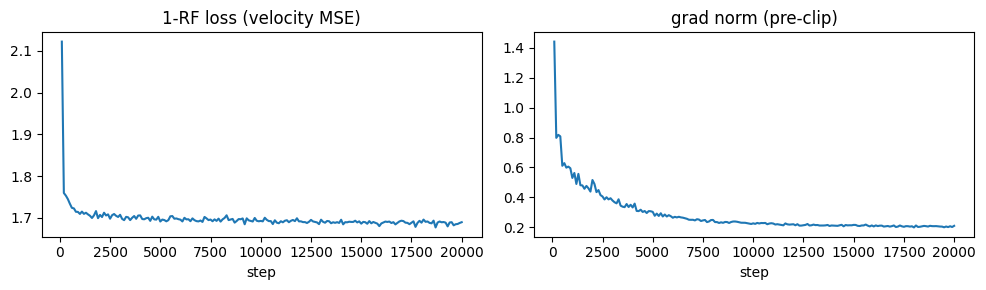

In [11]:
from halden.flow import make_rf_loss, make_reflow_loss, rf_sample, make_reflow_pairs, straightness, nfe_for

rf1_model = TimeMLP(dim=2, hidden=256, n_blocks=4)
rf1_ema, rf1_hist = train_generative(rf1_model, make_rf_loss(), X_train, device=DEVICE, **GEN_CONFIG)
vram = rf1_hist["peak_vram_mb"]
print(f"1-RF train wall-clock: {rf1_hist['train_seconds']:.1f}s | peak VRAM: "
      f"{'n/a (CPU)' if vram is None else f'{vram:.1f} MiB'} | final loss {rf1_hist['loss'][-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(rf1_hist["step"], rf1_hist["loss"]); ax[0].set_title("1-RF loss (velocity MSE)")
ax[1].plot(rf1_hist["step"], rf1_hist["grad_norm"]); ax[1].set_title("grad norm (pre-clip)")
for a in ax: a.set_xlabel("step")
plt.tight_layout(); plt.show()

### 2.2 Quality vs. sampling cost (no clipping)
Velocity prediction has no $1/\sqrt{\bar\alpha}$ amplification, so we sample with **no** $x_0$ clipping and no knowledge of the data bounds. `max|x|` is reported to show this.

In [12]:
def rf_sweep(model, grid, label):
    rows = []
    for n_steps, method in grid:
        x, sec, peak = measure(
            lambda: rf_sample(model, N_EVAL, n_steps, method, device=DEVICE, seed=0)[0],
            DEVICE, warmup_fn=lambda: rf_sample(model, 16, n_steps, method, device=DEVICE))
        x = x.cpu().numpy()
        m = evaluate_samples(x, X_ref)
        m.update(model=label, sampler=method, steps=n_steps, nfe=nfe_for(n_steps, method),
                 latency_s=sec, peak_vram_mb=peak, max_abs=float(np.abs(x).max()))
        rows.append(m)
    return rows

def print_rows(rows):
    print(f"{'model':>6} {'sampler':>7} {'NFE':>5} {'support':>8} {'SWD':>7} {'MMD':>8} {'max|x|':>7} {'latency s':>10}")
    for m in rows:
        print(f"{m.get('model', 'ddpm'):>6} {m['sampler']:>7} {m['nfe']:>5} {m['support_fraction']:>8.4f} "
              f"{m['swd']:>7.4f} {m['mmd']:>8.5f} {m.get('max_abs', float('nan')):>7.2f} {m['latency_s']:>10.3f}")
    print(f"{'floor':>6} {'':>7} {'':>5} {FLOOR['support_fraction']:>8.4f} {FLOOR['swd']:>7.4f} {FLOOR['mmd']:>8.5f}")

RF_GRID = [(1, "euler"), (2, "euler"), (5, "euler"), (10, "euler"), (25, "euler"),
           (50, "euler"), (100, "euler"), (250, "euler"), (5, "heun"), (25, "heun"), (50, "heun")]
rf1_sweep = rf_sweep(rf1_ema, RF_GRID, "1-RF")
print_rows(rf1_sweep)

 model sampler   NFE  support     SWD      MMD  max|x|  latency s
  1-RF   euler     1   0.4981  1.1398  4.17906    0.44      0.012
  1-RF   euler     2   0.4958  0.5093  0.27601    1.74      0.025
  1-RF   euler     5   0.8639  0.2133  0.03720    1.95      0.080
  1-RF   euler    10   0.9595  0.1091  0.00792    2.01      0.175
  1-RF   euler    25   0.9872  0.0442  0.00048    2.06      0.469
  1-RF   euler    50   0.9862  0.0242 -0.00020    2.09      0.958
  1-RF   euler   100   0.9829  0.0154 -0.00026    2.10      1.926
  1-RF   euler   250   0.9804  0.0121 -0.00020    2.11      4.871
  1-RF    heun    10   0.8630  0.0179  0.00027    2.36      0.181
  1-RF    heun    50   0.9697  0.0118 -0.00011    2.13      0.960
  1-RF    heun   100   0.9764  0.0118 -0.00012    2.12      1.952
 floor                 1.0000  0.0164  0.00009


### 2.3 Reflow → 2-RF
Couplings are generated with 100 Heun steps (200 NFE) from the trained 1-RF. 2-RF then trains with the same `GEN_CONFIG`. **Straightness** $S = \mathbb E_{t,z}\,\lVert (x_1 - z) - v_\theta(x_t, t)\rVert^2$ along the model's own trajectories; $S = 0$ means one Euler step is exact.

generated 100,000 reflow couplings in 20.2s
2-RF train 126.5s | total pipeline (1-RF + pairs + 2-RF) 273.6s
straightness: {'1-RF': 1.0606, '2-RF': 0.0}
 model sampler   NFE  support     SWD      MMD  max|x|  latency s
  2-RF   euler     1   0.9640  0.0117 -0.00009    2.22      0.015
  2-RF   euler     2   0.9672  0.0117 -0.00010    2.16      0.026
  2-RF   euler     5   0.9696  0.0117 -0.00011    2.13      0.081
  2-RF   euler    10   0.9711  0.0117 -0.00011    2.12      0.180
  2-RF   euler    25   0.9722  0.0117 -0.00011    2.12      0.467
  2-RF   euler    50   0.9727  0.0117 -0.00011    2.11      0.948
 floor                 1.0000  0.0164  0.00009


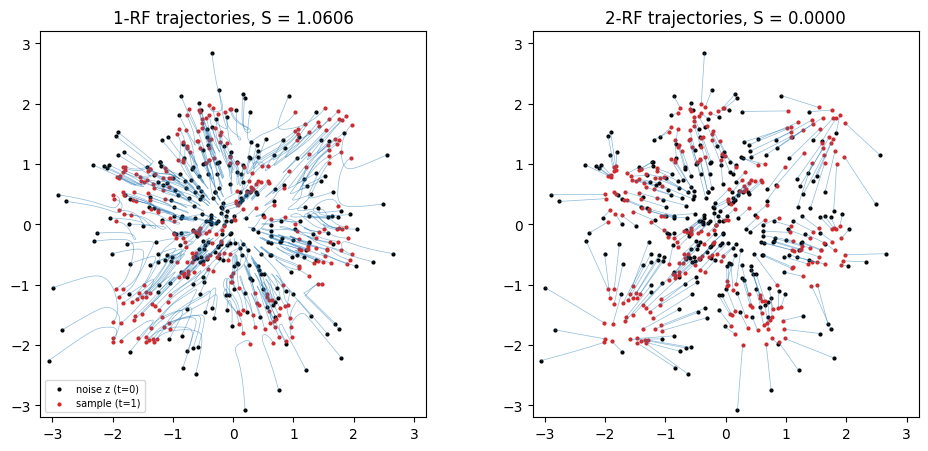

In [13]:
N_PAIRS = 20_000 if QUICK else 100_000
pairs, pair_sec, _ = measure(lambda: make_reflow_pairs(rf1_ema, N_PAIRS, n_steps=100, method="heun",
                                                       device=DEVICE), DEVICE)
print(f"generated {len(pairs):,} reflow couplings in {pair_sec:.1f}s")

rf2_model = TimeMLP(dim=2, hidden=256, n_blocks=4)
rf2_ema, rf2_hist = train_generative(rf2_model, make_reflow_loss(dim=2), pairs.numpy(),
                                     device=DEVICE, **GEN_CONFIG)
rf2_total_sec = rf1_hist["train_seconds"] + pair_sec + rf2_hist["train_seconds"]
print(f"2-RF train {rf2_hist['train_seconds']:.1f}s | total pipeline (1-RF + pairs + 2-RF) {rf2_total_sec:.1f}s")

S = {"1-RF": straightness(rf1_ema, device=DEVICE), "2-RF": straightness(rf2_ema, device=DEVICE)}
print("straightness:", {k: round(v, 4) for k, v in S.items()})

rf2_sweep = rf_sweep(rf2_ema, [(1, "euler"), (2, "euler"), (5, "euler"), (10, "euler"),
                               (25, "euler"), (50, "euler")], "2-RF")
print_rows(rf2_sweep)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
for a, model, name in zip(ax, (rf1_ema, rf2_ema), ("1-RF", "2-RF")):
    _, traj = rf_sample(model, 300, 50, "euler", device=DEVICE, seed=3, record=True)
    path = torch.stack(traj).numpy()          # (steps+1, n, 2)
    a.plot(path[:, :, 0], path[:, :, 1], lw=0.5, alpha=0.5, color="C0")
    a.scatter(*path[0].T, s=4, c="k", label="noise z (t=0)")
    a.scatter(*path[-1].T, s=4, c="C3", label="sample (t=1)")
    a.set_title(f"{name} trajectories, S = {S[name]:.4f}"); a.set_aspect("equal")
    a.set_xlim(-3.2, 3.2); a.set_ylim(-3.2, 3.2)
ax[0].legend(loc="lower left", fontsize=7)
plt.tight_layout(); plt.show()

### 2.4 Head-to-head: DDPM vs 1-RF vs 2-RF
Same backbone, data, training budget and metrics. Training cost for 2-RF includes the 1-RF it distills from.

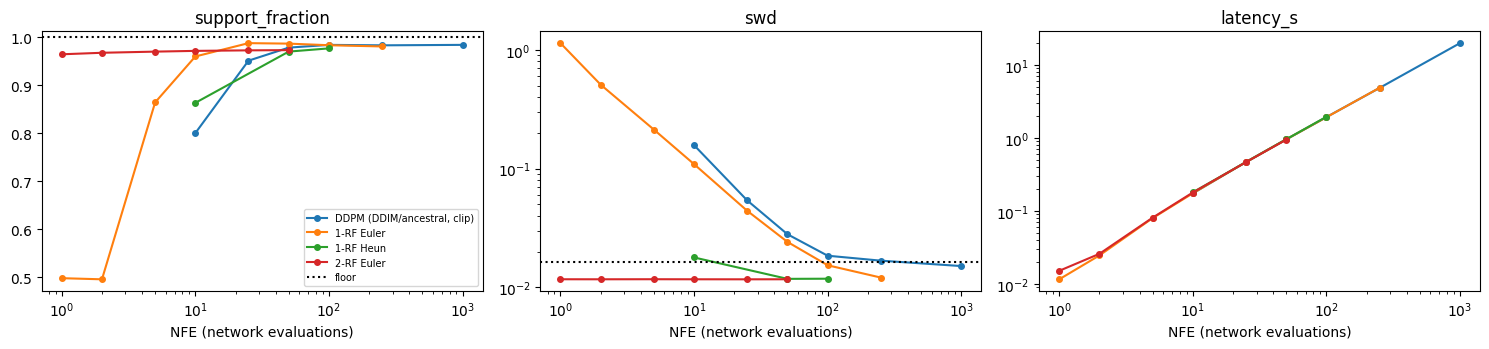

method  train s  VRAM MiB | best SWD @NFE<=1 / <=10 / <=50 / any
  DDPM    130.9      79.4 |    --     0.158@10  0.028@50  0.015@1000
  1-RF    126.8      89.6 | 1.140@1  0.018@10  0.012@50  0.012@50
  2-RF    273.6     100.9 | 0.012@1  0.012@2  0.012@25  0.012@25
floor SWD 0.016


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
series = {"DDPM (DDIM/ancestral, clip)": ddpm_sweep,
          "1-RF Euler": [m for m in rf1_sweep if m["sampler"] == "euler"],
          "1-RF Heun": [m for m in rf1_sweep if m["sampler"] == "heun"],
          "2-RF Euler": rf2_sweep}
for name, rows in series.items():
    rows = sorted(rows, key=lambda m: m["nfe"])
    for a, key in zip(ax, ("support_fraction", "swd", "latency_s")):
        a.plot([m["nfe"] for m in rows], [m[key] for m in rows], "o-", ms=4, label=name)
for a, key in zip(ax, ("support_fraction", "swd", "latency_s")):
    if key in FLOOR: a.axhline(FLOOR[key], color="k", ls=":", label="floor")
    a.set_xscale("log"); a.set_xlabel("NFE (network evaluations)"); a.set_title(key)
ax[1].set_yscale("log"); ax[2].set_yscale("log"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

def best_at(rows, max_nfe):
    ok = [m for m in rows if m["nfe"] <= max_nfe]
    return min(ok, key=lambda m: m["swd"]) if ok else None

train_cost = {"DDPM": (ddpm_hist["train_seconds"], ddpm_hist["peak_vram_mb"]),
              "1-RF": (rf1_hist["train_seconds"], rf1_hist["peak_vram_mb"]),
              "2-RF": (rf2_total_sec, rf2_hist["peak_vram_mb"])}
all_rows = {"DDPM": ddpm_sweep, "1-RF": rf1_sweep, "2-RF": rf2_sweep}
print(f"{'method':>6} {'train s':>8} {'VRAM MiB':>9} | best SWD @NFE<=1 / <=10 / <=50 / any")
for k, rows in all_rows.items():
    sec, vr = train_cost[k]
    cells = []
    for budget in (1, 10, 50, 10_000):
        b = best_at(rows, budget)
        cells.append("   --   " if b is None else f"{b['swd']:.3f}@{b['nfe']}")
    print(f"{k:>6} {sec:>8.1f} {'n/a' if vr is None else f'{vr:.1f}':>9} | " + "  ".join(cells))
print(f"floor SWD {FLOOR['swd']:.3f}")

In [15]:
RESULTS["rf"] = {
    "rf1": {"train_seconds": rf1_hist["train_seconds"], "train_peak_vram_mb": rf1_hist["peak_vram_mb"],
            "final_loss": rf1_hist["loss"][-1], "straightness": S["1-RF"], "sweep": rf1_sweep},
    "rf2": {"train_seconds": rf2_hist["train_seconds"], "pair_gen_seconds": pair_sec,
            "pipeline_seconds": rf2_total_sec, "train_peak_vram_mb": rf2_hist["peak_vram_mb"],
            "n_pairs": N_PAIRS, "straightness": S["2-RF"], "sweep": rf2_sweep},
}
json.dump(RESULTS, open("results/results.json", "w"), indent=2)
torch.save(rf1_ema.state_dict(), "checkpoints/rf1_ema.pt")
torch.save(rf2_ema.state_dict(), "checkpoints/rf2_ema.pt")
print("saved results/results.json and RF checkpoints")

saved results/results.json and RF checkpoints


## Part 3 — Fourier Neural Operator on Burgers

Learn $\mathcal G: u(\cdot, 0) \mapsto u(\cdot, T)$ from the 1000 training pairs of Part 0 ($\nu = 0.005$, $T = 0.5$).

**FNO-1d:** input $[u_0(x), x]$ → lift to 64 channels → 4 Fourier layers (16 modes each, plus a pointwise linear skip) → project to 1 channel. Spectral weights act on Fourier modes rather than grid points, so one trained model can be evaluated on any grid with at least 32 points.

**Training:** at $N = 128$ (stride-8 subsample of the $N = 1024$ data), relative-L2 loss, AdamW + cosine LR, batch 20.

### 3.1 Train

FNO params: 287,425
train wall-clock 113.9s | peak VRAM 88.5 MiB | final train relL2 0.0012 | test relL2 0.0028


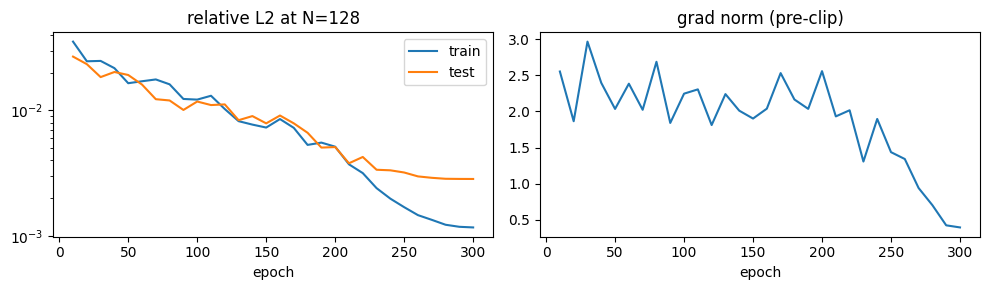

In [16]:
from halden.fno import FNO1d, train_operator, predict, per_sample_rel_l2, evaluate

N_TRAIN_GRID = 128
FNO_CONFIG = dict(epochs=30 if QUICK else 300, batch_size=20, lr=1e-3, weight_decay=1e-4,
                  eval_every=5 if QUICK else 10, seed=0)

def at(split, n):
    return subsample(split["u0"], n), subsample(split["uT"], n)

fno = FNO1d(modes=16, width=64, n_layers=4)
print(f"FNO params: {count_params(fno):,}")
fno_hist = train_operator(fno, at(bg_train, N_TRAIN_GRID), at(bg_test, N_TRAIN_GRID),
                          device=DEVICE, **FNO_CONFIG)
vram = fno_hist["peak_vram_mb"]
print(f"train wall-clock {fno_hist['train_seconds']:.1f}s | peak VRAM "
      f"{'n/a (CPU)' if vram is None else f'{vram:.1f} MiB'} | "
      f"final train relL2 {fno_hist['train_rel_l2'][-1]:.4f} | test relL2 {fno_hist['test_rel_l2'][-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].semilogy(fno_hist["epoch"], fno_hist["train_rel_l2"], label="train")
ax[0].semilogy(fno_hist["epoch"], fno_hist["test_rel_l2"], label="test")
ax[0].set_title(f"relative L2 at N={N_TRAIN_GRID}"); ax[0].legend()
ax[1].plot(fno_hist["epoch"], fno_hist["grad_norm"]); ax[1].set_title("grad norm (pre-clip)")
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.show()

### 3.2 Accuracy across evaluation grids
Same weights, no retraining. Ground truth at every resolution is the $N = 1024$ solver output, subsampled. We report the mean and the tail (95th percentile, max), because for engineering use the worst cases matter more than the average.

 N_eval  mean relL2   median      p95      max
     32      0.0059   0.0041   0.0166   0.0524
     64      0.0029   0.0023   0.0056   0.0463
    128      0.0028   0.0022   0.0056   0.0470  <- training grid
    256      0.0028   0.0022   0.0057   0.0471
    512      0.0028   0.0022   0.0057   0.0472
   1024      0.0028   0.0022   0.0057   0.0472
(baseline: predicting u(T) = u(0) gives relL2 0.977)


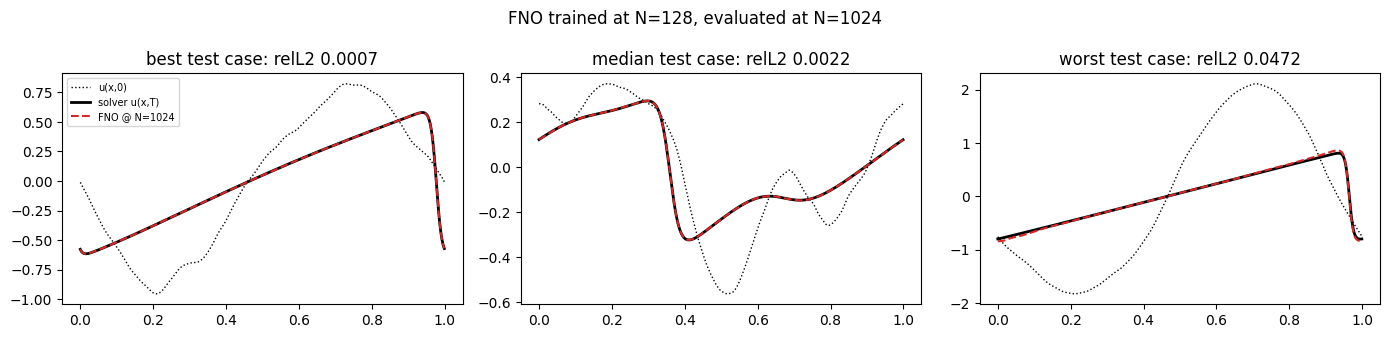

In [17]:
EVAL_GRIDS = [32, 64, 128, 256, 512, 1024]
fno_res = []
print(f"{'N_eval':>7} {'mean relL2':>11} {'median':>8} {'p95':>8} {'max':>8}")
for n in EVAL_GRIDS:
    u0_n, uT_n = at(bg_test, n)
    e = per_sample_rel_l2(predict(fno, u0_n, DEVICE), uT_n)
    row = dict(n_eval=n, mean=float(e.mean()), median=float(np.median(e)),
               p95=float(np.percentile(e, 95)), max=float(e.max()))
    fno_res.append(row)
    flag = "  <- training grid" if n == N_TRAIN_GRID else ""
    print(f"{n:>7} {row['mean']:>11.4f} {row['median']:>8.4f} {row['p95']:>8.4f} {row['max']:>8.4f}{flag}")
ident = per_sample_rel_l2(bg_test["u0"], bg_test["uT"]).mean()
print(f"(baseline: predicting u(T) = u(0) gives relL2 {ident:.3f})")

pred_fine = predict(fno, bg_test["u0"], DEVICE)
errs_fine = per_sample_rel_l2(pred_fine, bg_test["uT"])
order = np.argsort(errs_fine)
picks = {"best": order[0], "median": order[len(order) // 2], "worst": order[-1]}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, (name, i) in zip(axes, picks.items()):
    ax.plot(bg_test["x"], bg_test["u0"][i], "k:", lw=1, label="u(x,0)")
    ax.plot(bg_test["x"], bg_test["uT"][i], "k", lw=2, label="solver u(x,T)")
    ax.plot(bg_test["x"], pred_fine[i], "C3--", lw=1.5, label="FNO @ N=1024")
    ax.set_title(f"{name} test case: relL2 {errs_fine[i]:.4f}")
axes[0].legend(fontsize=7)
plt.suptitle(f"FNO trained at N={N_TRAIN_GRID}, evaluated at N=1024"); plt.tight_layout(); plt.show()

### 3.3 Cost: FNO vs. running the solver
The relevant question for Halden is whether the surrogate is cheaper than simply running the solver at the accuracy we need. Both run in PyTorch on the same device. The coarse solver ($N = 128$) is the cheap classical baseline, and its error is measured against the fine solver just like the FNO's.

In [18]:
n_cases = len(bg_test["u0"])
cost = {}
for n in (128, 1024):
    u0_n, uT_n = at(bg_test, n)
    pred, sec, peak = measure(lambda: predict(fno, u0_n, DEVICE), DEVICE,
                              warmup_fn=lambda: predict(fno, u0_n[:4], DEVICE), repeats=5)
    cost[f"FNO @ N={n}"] = dict(seconds=sec, peak_vram_mb=peak,
                                rel_l2=float(per_sample_rel_l2(pred, uT_n).mean()))
for n in (128, 1024):
    u0_n, uT_n = at(bg_test, n)
    sol, sec, peak = measure(lambda: solve_burgers(u0_n, NU, T_FINAL, device=DEVICE), DEVICE)
    cost[f"solver @ N={n}"] = dict(seconds=sec, peak_vram_mb=peak,
                                   rel_l2=float(per_sample_rel_l2(sol, uT_n).mean()))

ref_sec = cost["solver @ N=1024"]["seconds"]
print(f"{n_cases} test cases on {DEVICE}")
print(f"{'method':>16} {'seconds':>9} {'ms/case':>8} {'speedup':>8} {'relL2 vs fine':>14} {'VRAM MiB':>9}")
for k, c in cost.items():
    v = c["peak_vram_mb"]
    print(f"{k:>16} {c['seconds']:>9.4f} {1000 * c['seconds'] / n_cases:>8.3f} "
          f"{ref_sec / c['seconds']:>7.0f}x {c['rel_l2']:>14.4f} {'n/a' if v is None else f'{v:.1f}':>9}")
print("(solver @ N=1024 relL2 is 0 by definition: it is the ground truth.)")

200 test cases on cuda
          method   seconds  ms/case  speedup  relL2 vs fine  VRAM MiB
     FNO @ N=128    0.0048    0.024     709x         0.0028      83.3
    FNO @ N=1024    0.0279    0.140     121x         0.0028     302.8
  solver @ N=128    0.3455    1.727      10x         0.0084      53.8
 solver @ N=1024    3.3714   16.857       1x         0.0000      69.8
(solver @ N=1024 relL2 is 0 by definition: it is the ground truth.)


In [19]:
RESULTS["fno"] = {
    "params": count_params(fno),
    "train_grid": N_TRAIN_GRID,
    "train_seconds": fno_hist["train_seconds"],
    "train_peak_vram_mb": fno_hist["peak_vram_mb"],
    "config": fno_hist["config"],
    "final_test_rel_l2": fno_hist["test_rel_l2"][-1],
    "resolution_sweep": fno_res,
    "cost": cost,
}
json.dump(RESULTS, open("results/results.json", "w"), indent=2)
torch.save(fno.state_dict(), "checkpoints/fno.pt")
print("saved results/results.json and checkpoints/fno.pt")

saved results/results.json and checkpoints/fno.pt


## Part 4 — Deliberate failures, diagnosis, and repair

Each failure is **induced** on purpose, **diagnosed** from recorded evidence, **repaired**, and given a **guard**: an automated check that would catch it before any GPU-cluster scale-up. Everything goes into a structured `FailureLog`, written to `results/failure_log.md` and `.json`.

| ID | Model | Induced failure |
|---|---|---|
| F1 | DDPM | Sampled with a different noise schedule than it was trained with |
| F2 | Rectified flow | Exploding learning rate |
| F3 | FNO | Resolution mismatch between training and evaluation grids (coordinate-channel bug) |

In [20]:
from halden.failures import (FailureLog, per_timestep_eps_error, prediction_collapse, param_norm,
                             IndexGridFNO, resolution_consistency)
from halden.ddpm import fingerprint, check_schedule

FAILLOG = FailureLog()

def cell_mass(x):
    # Fraction of samples in each of the 16 board cells (true value: 0.125 on black, 0 on white).
    idx = np.floor(x + 2).astype(int)
    ok = ((idx >= 0) & (idx < 4)).all(1)
    cells = np.zeros((4, 4))
    np.add.at(cells, (idx[ok, 0], idx[ok, 1]), 1)
    return cells / len(x)

### F1 — DDPM: mismatched noise schedule

**Induce:** take the DDPM trained in Part 1 with the **linear** schedule and sample it with the **cosine** schedule. Nothing errors and the samples still look like a checkerboard at a glance. This is the kind of mistake that happens when a sampler config and a checkpoint drift apart.

matched  (linear/linear) ancestral, clip: support_fraction 0.9837 | swd 0.0151 | mmd -0.0002 | std 1.147
MISMATCH (linear/cosine) ancestral, clip: support_fraction 0.9394 | swd 0.3318 | mmd 0.1060 | std 0.849
MISMATCH (linear/cosine) DDIM-50, clip:    support_fraction 0.7541 | swd 0.3970 | mmd 0.1596
reference std 1.153

cell mass, mismatched (true: 0.125 on each black cell):
 [[0.045 0.006 0.095 0.001]
 [0.006 0.232 0.018 0.098]
 [0.089 0.019 0.243 0.005]
 [0.001 0.093 0.005 0.044]]


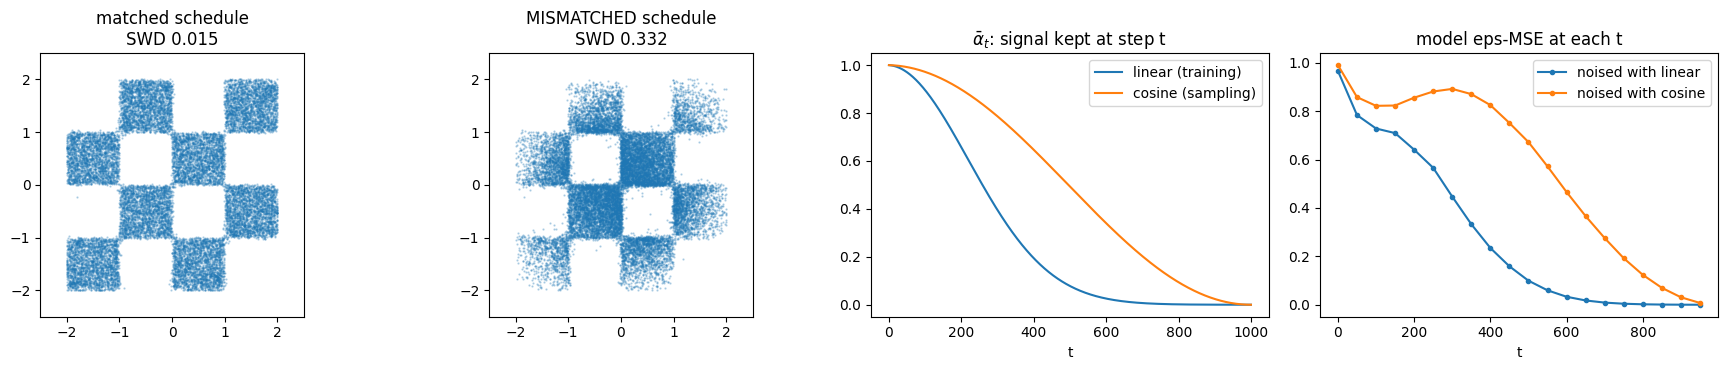

In [21]:
COSINE = make_schedule("cosine", T=1000)
# Clip x0 in both runs so the schedule is the only variable that differs.
f1_x, _ = ddpm_sample(ddpm_ema, COSINE, N_EVAL, device=DEVICE, seed=0, clip_x0=2.0)
f1_x = f1_x.cpu().numpy()
f1_m = evaluate_samples(f1_x, X_ref)
f1_ddim = evaluate_samples(ddim_sample(ddpm_ema, COSINE, N_EVAL, 50, device=DEVICE, seed=0,
                                       clip_x0=2.0).cpu().numpy(), X_ref)
ok_x = ddpm_runs["clip"][0]
ok_m = ddpm_runs["clip"][2]
print("matched  (linear/linear) ancestral, clip:", fmt(ok_m), f"| std {ok_x.std():.3f}")
print("MISMATCH (linear/cosine) ancestral, clip:", fmt(f1_m), f"| std {f1_x.std():.3f}")
print("MISMATCH (linear/cosine) DDIM-50, clip:   ", fmt(f1_ddim))
print(f"reference std {X_ref.std():.3f}")
print("\ncell mass, mismatched (true: 0.125 on each black cell):\n", cell_mass(f1_x).round(3))

# Diagnosis: what noise level does the network see at each t, vs what it was trained on?
ts = list(range(0, 1000, 50))
err_lin = per_timestep_eps_error(ddpm_ema, X_ref[:5000], SCHED, ts, DEVICE)
err_cos = per_timestep_eps_error(ddpm_ema, X_ref[:5000], COSINE, ts, DEVICE)

fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
ax[0].scatter(*ok_x.T, s=0.4, alpha=0.3); ax[0].set_title(f"matched schedule\nSWD {ok_m['swd']:.3f}")
ax[1].scatter(*f1_x.T, s=0.4, alpha=0.3); ax[1].set_title(f"MISMATCHED schedule\nSWD {f1_m['swd']:.3f}")
for a in ax[:2]: a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5); a.set_aspect("equal")
ax[2].plot(SCHED.alpha_bars.numpy(), label="linear (training)")
ax[2].plot(COSINE.alpha_bars.numpy(), label="cosine (sampling)")
ax[2].set_title(r"$\bar\alpha_t$: signal kept at step t"); ax[2].legend(); ax[2].set_xlabel("t")
ax[3].plot(ts, err_lin, "o-", ms=3, label="noised with linear")
ax[3].plot(ts, err_cos, "o-", ms=3, label="noised with cosine")
ax[3].set_title("model eps-MSE at each t"); ax[3].legend(); ax[3].set_xlabel("t")
plt.tight_layout(); plt.show()

**Diagnosis.** Both runs use the same weights and the same $x_0$ clipping; only the schedule differs. Support fraction moves far less than SWD and MMD, and the sample std shrinks: the cell-mass table shows mass pulled toward the centre of the board. The right two panels show why. At the same step index $t$, the cosine schedule keeps much more signal ($\bar\alpha_t$ is higher). The network was told "step $t$", so it assumes the linear schedule's (higher) noise level, removes too much noise, and pulls every sample toward the data mean. Its $\varepsilon$-error under the cosine schedule is far above the error under the schedule it was trained on, at every mid-range $t$.

**Repair:** sample with the training schedule. **Guard:** store a fingerprint of the exact betas in the checkpoint and refuse to sample when it doesn't match. Also refuse schedules whose $\bar\alpha_T$ is too large for $x_T \sim \mathcal N(0, I)$ to hold.

In [22]:
DDPM_FP = fingerprint(SCHED)
torch.save({"state_dict": ddpm_ema.state_dict(), "schedule_fingerprint": DDPM_FP}, "checkpoints/ddpm_ema.pt")
print("checkpoint schedule fingerprint:", DDPM_FP)

guard_msgs = []
# (a) checkpoint/sampler drift: fingerprint check; (b) a schedule that never reaches pure noise:
#     terminal-SNR check, which needs no checkpoint at all.
for bad, expected in ((COSINE, DDPM_FP), (make_schedule("linear", T=1000, beta_end=0.002, name="linear-weak"), None)):
    try:
        check_schedule(bad, expected=expected)
    except ValueError as e:
        guard_msgs.append(str(e)); print("guard raised:", e)
check_schedule(SCHED, expected=DDPM_FP); print("guard passes for the training schedule")

FAILLOG.add(
    id="F1", model="DDPM", title="Mismatched noise schedule (train linear, sample cosine)",
    induced_by="Sampled the linear-schedule DDPM checkpoint with make_schedule('cosine').",
    symptom=(f"No error raised. Support {ok_m['support_fraction']:.3f} -> {f1_m['support_fraction']:.3f}, "
             f"SWD {ok_m['swd']:.3f} -> {f1_m['swd']:.3f} ({f1_m['swd'] / ok_m['swd']:.1f}x); sample std "
             f"{f1_x.std():.2f} vs reference {X_ref.std():.2f}; centre-cell mass {cell_mass(f1_x)[1, 1]:.3f}, "
             f"corner {cell_mass(f1_x)[0, 0]:.3f} (true 0.125)."),
    evidence_broken={"support_fraction": f1_m["support_fraction"], "swd": f1_m["swd"], "mmd": f1_m["mmd"],
                     "sample_std": float(f1_x.std()), "reference_std": float(X_ref.std()),
                     "corner_cell_mass": float(cell_mass(f1_x)[0, 0]),
                     "centre_cell_mass": float(cell_mass(f1_x)[1, 1]),
                     "ddim50_swd": f1_ddim["swd"],
                     "eps_mse_mid_t_cosine": float(err_cos[len(ts) // 2]),
                     "eps_mse_mid_t_linear": float(err_lin[len(ts) // 2])},
    diagnosis=("Support fraction moves far less than SWD/MMD and per-cell mass, so it is not a sufficient check. "
               "Per-timestep eps-error under the sampling schedule is far above the training-schedule error "
               "at mid-range t, which isolates the cause to the t -> noise-level mapping, not the weights."),
    root_cause=("The network is conditioned on the step index t, so it implicitly learns abar_t of the training "
                "schedule. Cosine keeps more signal at each t, so the model over-denoises and contracts samples "
                "toward the mean."),
    repair="Sample with the exact schedule used in training (the Part 1 linear schedule).",
    evidence_repaired={"support_fraction": ok_m["support_fraction"], "swd": ok_m["swd"], "mmd": ok_m["mmd"],
                       "sample_std": float(ok_x.std()), "metric_floor_swd": FLOOR["swd"]},
    guard=("checkpoint stores schedule_fingerprint (sha1 of betas); ddpm.check_schedule raises on mismatch "
           "and on abar_T > 1e-3. Report SWD/MMD, not support fraction alone."),
)

checkpoint schedule fingerprint: linear-T1000-23bd7873f9
guard raised: sampling schedule cosine-T1000-d1595e47a6 != training schedule linear-T1000-23bd7873f9
guard raised: abar_T = 3.50e-01 > 1e-03: x_T is not pure noise
guard passes for the training schedule


### F2 — Rectified flow: exploding learning rate

**Diagnose first with an LR range test:** short identical runs (no warmup) across six orders of magnitude of LR. For each one we record the final loss and a **collapse ratio**: the spread of the model's predictions divided by the spread of its target. The loss of a network that outputs a constant is computable in closed form, $\mathrm{Var}(x) + \mathrm{Var}(z) \approx 2.33$ per coordinate, and gives us the "dead model" line.

     lr  final loss  peak loss  peak |g|  pred/target std
  1e-04       1.709       2.17      1.16            0.440
  3e-04       1.693       1.99      1.14            0.503
  1e-03       1.690       1.96      1.47            0.482
  3e-03       1.690       2.05      1.75            0.500
  1e-02       1.690       2.18      2.26            0.407
  3e-02       1.717       2.83      3.66            0.348
  1e-01       2.318       4.72      7.36            0.003
  3e-01       2.318      29.88     29.53            0.023
  1e+00       2.319    2229.29    805.31            0.379
constant-predictor ('dead model') loss = 2.322


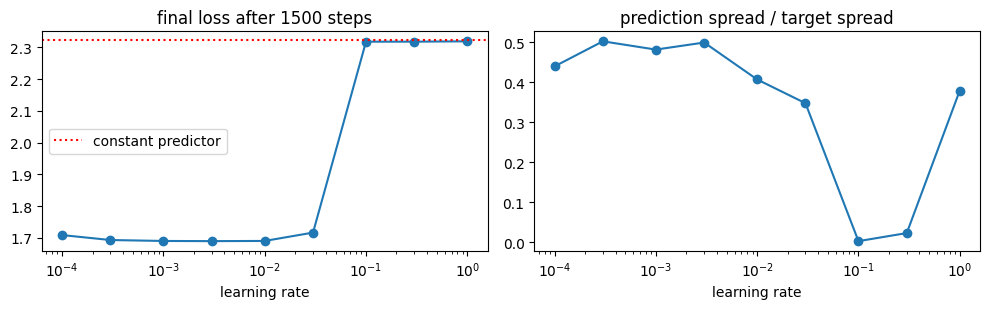

In [23]:
LR_GRID = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]
RANGE_STEPS = 300 if QUICK else 1500
lr_rows = []
for lr in LR_GRID:
    cfg = dict(GEN_CONFIG, steps=RANGE_STEPS, lr=lr, warmup=0, log_every=50)
    ema, h = train_generative(TimeMLP(), make_rf_loss(), X_train, device=DEVICE, **cfg)
    pc = prediction_collapse(ema, X_ref[:4000], device=DEVICE)
    lr_rows.append(dict(lr=lr, final_loss=h["loss"][-1], peak_loss=max(h["loss"]),
                        peak_grad_norm=max(h["grad_norm"]), collapse_ratio=pc["ratio"]))
DEAD_LOSS = pc["mean_baseline_loss"]

print(f"{'lr':>7} {'final loss':>11} {'peak loss':>10} {'peak |g|':>9} {'pred/target std':>16}")
for r in lr_rows:
    print(f"{r['lr']:>7.0e} {r['final_loss']:>11.3f} {r['peak_loss']:>10.2f} {r['peak_grad_norm']:>9.2f} "
          f"{r['collapse_ratio']:>16.3f}")
print(f"constant-predictor ('dead model') loss = {DEAD_LOSS:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].semilogx([r["lr"] for r in lr_rows], [r["final_loss"] for r in lr_rows], "o-")
ax[0].axhline(DEAD_LOSS, color="r", ls=":", label="constant predictor"); ax[0].legend()
ax[0].set_title(f"final loss after {RANGE_STEPS} steps"); ax[0].set_xlabel("learning rate")
ax[1].semilogx([r["lr"] for r in lr_rows], [r["collapse_ratio"] for r in lr_rows], "o-")
ax[1].set_title("prediction spread / target spread"); ax[1].set_xlabel("learning rate")
plt.tight_layout(); plt.show()

**Induce at full scale:** train 1-RF with `lr = 1.0` and no warmup, then try the "obvious" fix of gradient clipping at the same LR. Compare both against the Part 2 baseline (`lr = 1e-3`, 500-step warmup).

               run  peak loss  final loss  peak |g|  pred/tgt std  |theta|  support     SWD
            lr=1.0    2229.31       2.321     805.3         0.012   5473.2    0.458   0.263
 lr=1.0 + clip 1.0    2290.63       2.321     694.9         0.000   5580.5    0.454   0.253
  baseline lr=1e-3       2.12       1.689       1.4         0.530     62.6    0.987   0.044


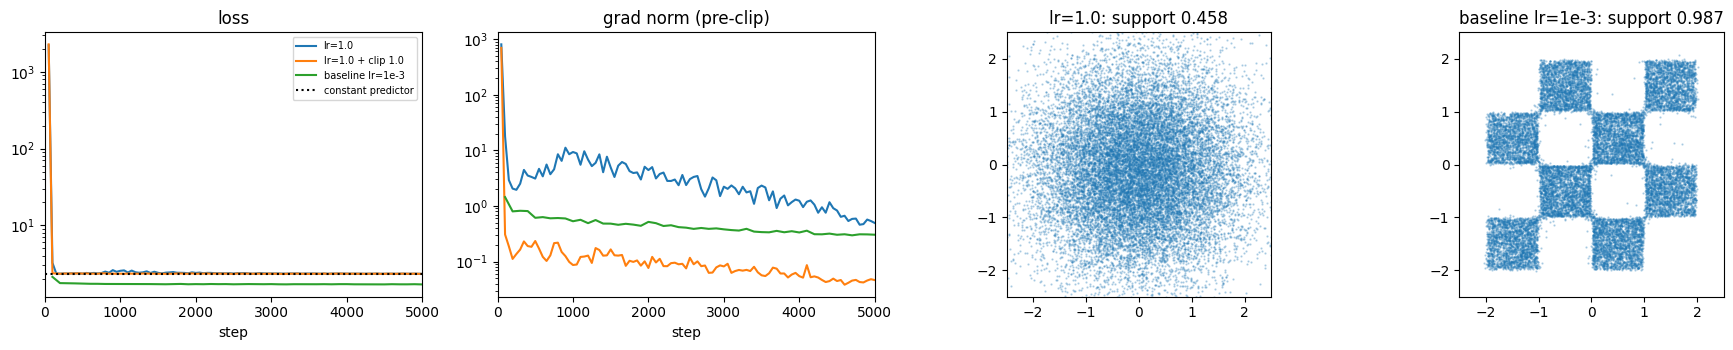

In [24]:
F2_STEPS = 800 if QUICK else 5000
f2_runs = {}
for name, extra in {"lr=1.0": dict(lr=1.0, warmup=0),
                    "lr=1.0 + clip 1.0": dict(lr=1.0, warmup=0, grad_clip=1.0)}.items():
    cfg = dict(GEN_CONFIG, steps=F2_STEPS, log_every=50, **extra)
    model = TimeMLP()
    ema, h = train_generative(model, make_rf_loss(), X_train, device=DEVICE, **cfg)
    x = rf_sample(ema, N_EVAL, 25, "euler", device=DEVICE, seed=0)[0].cpu().numpy()
    f2_runs[name] = dict(hist=h, metrics=evaluate_samples(x, X_ref), x=x,
                         collapse=prediction_collapse(ema, X_ref[:4000], device=DEVICE),
                         param_norm=param_norm(model))
base_x = rf_sample(rf1_ema, N_EVAL, 25, "euler", device=DEVICE, seed=0)[0].cpu().numpy()
f2_runs["baseline lr=1e-3"] = dict(hist=rf1_hist, metrics=evaluate_samples(base_x, X_ref), x=base_x,
                                   collapse=prediction_collapse(rf1_ema, X_ref[:4000], device=DEVICE),
                                   param_norm=param_norm(rf1_model))

print(f"{'run':>18} {'peak loss':>10} {'final loss':>11} {'peak |g|':>9} {'pred/tgt std':>13} "
      f"{'|theta|':>8} {'support':>8} {'SWD':>7}")
for name, r in f2_runs.items():
    h = r["hist"]
    print(f"{name:>18} {max(h['loss']):>10.2f} {h['loss'][-1]:>11.3f} {max(h['grad_norm']):>9.1f} "
          f"{r['collapse']['ratio']:>13.3f} {r['param_norm']:>8.1f} "
          f"{r['metrics']['support_fraction']:>8.3f} {r['metrics']['swd']:>7.3f}")

fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
for name, r in f2_runs.items():
    h = r["hist"]
    ax[0].semilogy(h["step"], h["loss"], label=name)
    ax[1].semilogy(h["step"], h["grad_norm"], label=name)
ax[0].axhline(DEAD_LOSS, color="k", ls=":", label="constant predictor")
ax[0].set_title("loss"); ax[1].set_title("grad norm (pre-clip)"); ax[0].legend(fontsize=7)
for a in ax[:2]: a.set_xlabel("step"); a.set_xlim(0, F2_STEPS)
for a, name in zip(ax[2:], ("lr=1.0", "baseline lr=1e-3")):
    a.scatter(*f2_runs[name]["x"].T, s=0.4, alpha=0.3)
    a.set_title(f"{name}: support {f2_runs[name]['metrics']['support_fraction']:.3f}")
    a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5); a.set_aspect("equal")
plt.tight_layout(); plt.show()

**Diagnosis.** The explosion is brief: loss and gradient norm spike in the first logging window, then settle. After that the run looks *calm*. There's no NaN and the gradient norm is small. But the loss is pinned at the constant-predictor level, and the prediction spread is far below the baseline's. The network is dead: the oversized early updates inflate the weights ($\lVert\theta\rVert$ is far above the baseline), the activations saturate, and the model outputs one vector for every input.

**Why clipping doesn't fix it.** Adam divides each update by a running RMS of the gradient, so the step size is ≈ `lr` *regardless of gradient magnitude*. Clipping rescales the gradient, Adam undoes that, and the steps stay huge. Clipping is a real fix for SGD-style optimizers, not for Adam at a bad LR.

**Repair:** LR inside the stable band from the range test, plus warmup (the Part 2 config, `lr = 1e-3`, 500 warmup steps). **Guard:** run the range test before any new scale or architecture, and fail the run if the loss sits at the constant-predictor level. That is the clean signal in the range test. Prediction spread and parameter norm are supporting evidence; in short runs the spread is noisy even for healthy LRs.

In [25]:
stable = [r["lr"] for r in lr_rows if r["final_loss"] < 0.95 * DEAD_LOSS]
broken, clipped, base = f2_runs["lr=1.0"], f2_runs["lr=1.0 + clip 1.0"], f2_runs["baseline lr=1e-3"]
FAILLOG.add(
    id="F2", model="Rectified flow (1-RF)", title="Exploding learning rate",
    induced_by="Adam lr = 1.0 with no warmup (baseline: lr = 1e-3, 500-step warmup); second run adds grad_clip = 1.0.",
    symptom=("Loss and grad-norm spike in the first logging window, then a calm-looking plateau at the "
             "constant-predictor loss; no NaN, so nothing crashes. Samples collapse."),
    evidence_broken={"peak_loss": max(broken["hist"]["loss"]), "final_loss": broken["hist"]["loss"][-1],
                     "constant_predictor_loss": DEAD_LOSS, "peak_grad_norm": max(broken["hist"]["grad_norm"]),
                     "pred_to_target_std": broken["collapse"]["ratio"], "param_norm": broken["param_norm"],
                     "support_fraction": broken["metrics"]["support_fraction"], "swd": broken["metrics"]["swd"],
                     "with_clip_final_loss": clipped["hist"]["loss"][-1],
                     "with_clip_pred_to_target_std": clipped["collapse"]["ratio"],
                     "with_clip_swd": clipped["metrics"]["swd"]},
    diagnosis=("LR range test shows a stable band and a cliff: above it the final loss equals the closed-form "
               "constant-predictor loss Var(x)+Var(z) and prediction spread -> 0. Gradient clipping at the same LR "
               f"leaves the loss at {clipped['hist']['loss'][-1]:.3f}, ruling out gradient magnitude as the lever."),
    root_cause=("Adam's update is ~lr per parameter irrespective of gradient scale, so lr = 1.0 moves every weight "
                "by O(1) per step; weights blow up, activations saturate and the network becomes a constant "
                "function from which gradients cannot recover it."),
    repair=(f"lr = 1e-3 with 500-step linear warmup and cosine decay; range test: LRs that avoid collapse {stable}, "
            f"lowest final loss at {min(lr_rows, key=lambda r: r['final_loss'])['lr']:.0e}."),
    evidence_repaired={"final_loss": base["hist"]["loss"][-1], "pred_to_target_std": base["collapse"]["ratio"],
                       "param_norm": base["param_norm"], "support_fraction": base["metrics"]["support_fraction"],
                       "swd": base["metrics"]["swd"], "metric_floor_swd": FLOOR["swd"]},
    guard=("LR range test before each new scale/architecture; abort a run whose loss stays within 5% of the "
           f"closed-form constant-predictor loss; log parameter norm ({broken['param_norm'] / base['param_norm']:.0f}x "
           "baseline here) as a second alarm. "
           "Don't count on clipping with Adam."),
)

### F3 — FNO: resolution mismatch between training and evaluation grids

**Induce:** a common implementation slip. The coordinate channel is built as the grid **index** $j = 0, \dots, N-1$ instead of the physical coordinate $x_j = j/N$. Trained at $N = 128$ like the Part 3 model, it looks healthy on the training grid. Then Halden evaluates it on a finer grid.

 N_eval  correct FNO  index-grid FNO
     32       0.0059          0.4517
     64       0.0029          0.2356
    128       0.0028          0.0057  <- training grid
    256       0.0028          0.2321
    512       0.0028          0.3922
   1024       0.0028          0.4832

resolution-consistency gap (predict@1024 then subsample vs predict@128), no labels needed:
  correct FNO 0.0003 | index-grid FNO 0.4827
coordinate channel range: training N=128: [0, 127] | eval N=1024: [0, 1023] (correct model: [0, 1) at every N)


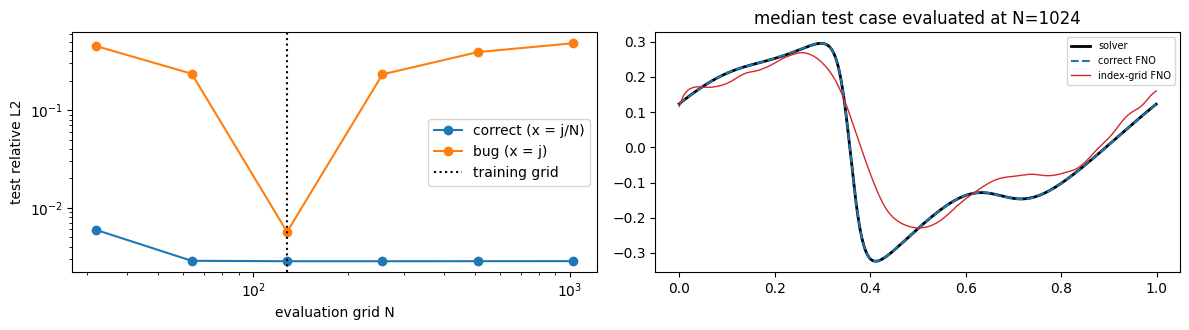

In [26]:
fno_bug = IndexGridFNO(modes=16, width=64, n_layers=4)
bug_hist = train_operator(fno_bug, at(bg_train, N_TRAIN_GRID), at(bg_test, N_TRAIN_GRID),
                          device=DEVICE, **FNO_CONFIG)

f3_rows = []
print(f"{'N_eval':>7} {'correct FNO':>12} {'index-grid FNO':>15}")
for n in EVAL_GRIDS:
    u0_n, uT_n = at(bg_test, n)
    good = float(per_sample_rel_l2(predict(fno, u0_n, DEVICE), uT_n).mean())
    bad = float(per_sample_rel_l2(predict(fno_bug, u0_n, DEVICE), uT_n).mean())
    f3_rows.append(dict(n_eval=n, correct=good, index_grid=bad))
    print(f"{n:>7} {good:>12.4f} {bad:>15.4f}{'  <- training grid' if n == N_TRAIN_GRID else ''}")

gap_bug = resolution_consistency(fno_bug, bg_test["u0"], N_TRAIN_GRID, DEVICE)
gap_ok = resolution_consistency(fno, bg_test["u0"], N_TRAIN_GRID, DEVICE)
print(f"\nresolution-consistency gap (predict@1024 then subsample vs predict@{N_TRAIN_GRID}), no labels needed:")
print(f"  correct FNO {gap_ok:.4f} | index-grid FNO {gap_bug:.4f}")
print(f"coordinate channel range: training N={N_TRAIN_GRID}: [0, {N_TRAIN_GRID - 1}] | eval N=1024: [0, 1023] "
      f"(correct model: [0, 1) at every N)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].loglog(EVAL_GRIDS, [r["correct"] for r in f3_rows], "o-", label="correct (x = j/N)")
ax[0].loglog(EVAL_GRIDS, [r["index_grid"] for r in f3_rows], "o-", label="bug (x = j)")
ax[0].axvline(N_TRAIN_GRID, color="k", ls=":", label="training grid")
ax[0].set_xlabel("evaluation grid N"); ax[0].set_ylabel("test relative L2"); ax[0].legend()
i = picks["median"]
ax[1].plot(bg_test["x"], bg_test["uT"][i], "k", lw=2, label="solver")
ax[1].plot(bg_test["x"], predict(fno, bg_test["u0"][i:i + 1], DEVICE)[0], "C0--", label="correct FNO")
ax[1].plot(bg_test["x"], predict(fno_bug, bg_test["u0"][i:i + 1], DEVICE)[0], "C3", lw=1, label="index-grid FNO")
ax[1].set_title("median test case evaluated at N=1024"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**Diagnosis.** The bug hides at the training resolution: the error there is plausible, if worse than the correct model's because the unnormalized coordinate also hurts optimization. Every other grid is broken, in both directions. The coordinate channel is the only input whose *values* depend on $N$. The spectral layers are resolution-agnostic, but the pointwise lift sees coordinates up to 1023 when it was trained on at most 127, which is far out of distribution.

The **resolution-consistency check** finds this **without any ground truth**: predict on the fine grid and subsample, predict on the coarse grid directly, and compare. A genuinely discretization-invariant operator gives ≈ 0.

**Repair:** physical coordinates $x_j = j/N \in [0, 1)$ (the Part 3 `FNO1d`). **Guard:** run `resolution_consistency` in CI on every operator checkpoint, at every grid it will be deployed on.

In [27]:
r_bug = {r["n_eval"]: r["index_grid"] for r in f3_rows}
r_ok = {r["n_eval"]: r["correct"] for r in f3_rows}
FAILLOG.add(
    id="F3", model="FNO-1d", title="Resolution mismatch between training and evaluation grids",
    induced_by=f"Coordinate channel built as grid index j instead of x = j/N; trained at N={N_TRAIN_GRID}, "
               "evaluated at N = 32 .. 1024.",
    symptom=(f"Plausible error on the training grid ({r_bug[N_TRAIN_GRID]:.3f}) but {r_bug[1024]:.3f} at N=1024 "
             f"and {r_bug[64]:.3f} at N=64; no error raised."),
    evidence_broken={f"rel_l2_N{n}": v for n, v in r_bug.items()} | {"consistency_gap": gap_bug},
    diagnosis=("Error is minimal only at the training N and grows in both directions. Only the coordinate "
               "channel's values change with N (range [0, N-1]), so the pointwise lift sees out-of-distribution "
               "inputs; spectral layers are not the cause. Label-free resolution-consistency gap confirms it."),
    root_cause=("Coordinates in index units make the input distribution resolution-dependent, breaking the "
                "discretization invariance that the Fourier layers otherwise provide."),
    repair="Use physical coordinates x_j = j/N on the periodic unit interval (FNO1d.grid).",
    evidence_repaired={f"rel_l2_N{n}": v for n, v in r_ok.items()} | {"consistency_gap": gap_ok},
    guard=("resolution_consistency(model, u0_fine, coarse) < 1e-2 at every deployment grid, checked in CI; "
           "always report error at more than one grid."),
)

### Failure log

In [28]:
from IPython.display import Markdown, display

FAILLOG.save("results")
RESULTS["failure_log"] = FAILLOG.entries
json.dump(RESULTS, open("results/results.json", "w"), indent=2, default=float)
print("wrote results/failure_log.md, results/failure_log.json, results/results.json")
display(Markdown(FAILLOG.to_markdown()))

wrote results/failure_log.md, results/failure_log.json, results/results.json


# Failure log

| ID | Model | Failure | Symptom | Repair |
|---|---|---|---|---|
| F1 | DDPM | Mismatched noise schedule (train linear, sample cosine) | No error raised. Support 0.984 -> 0.939, SWD 0.015 -> 0.332 (21.9x); sample std 0.85 vs reference 1.15; centre-cell mass 0.232, corner 0.045 (true 0.125). | Sample with the exact schedule used in training (the Part 1 linear schedule). |
| F2 | Rectified flow (1-RF) | Exploding learning rate | Loss and grad-norm spike in the first logging window, then a calm-looking plateau at the constant-predictor loss; no NaN, so nothing crashes. Samples collapse. | lr = 1e-3 with 500-step linear warmup and cosine decay; range test: LRs that avoid collapse [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03], lowest final loss at 3e-03. |
| F3 | FNO-1d | Resolution mismatch between training and evaluation grids | Plausible error on the training grid (0.006) but 0.483 at N=1024 and 0.236 at N=64; no error raised. | Use physical coordinates x_j = j/N on the periodic unit interval (FNO1d.grid). |

## F1: Mismatched noise schedule (train linear, sample cosine) (DDPM)

**Induced by:** Sampled the linear-schedule DDPM checkpoint with make_schedule('cosine').

**Symptom:** No error raised. Support 0.984 -> 0.939, SWD 0.015 -> 0.332 (21.9x); sample std 0.85 vs reference 1.15; centre-cell mass 0.232, corner 0.045 (true 0.125).

**Evidence (broken):**
  - support_fraction: 0.9394
  - swd: 0.3318
  - mmd: 0.106
  - sample_std: 0.8492
  - reference_std: 1.153
  - corner_cell_mass: 0.0454
  - centre_cell_mass: 0.2318
  - ddim50_swd: 0.397
  - eps_mse_mid_t_cosine: 0.672
  - eps_mse_mid_t_linear: 0.09948

**Diagnosis:** Support fraction moves far less than SWD/MMD and per-cell mass, so it is not a sufficient check. Per-timestep eps-error under the sampling schedule is far above the training-schedule error at mid-range t, which isolates the cause to the t -> noise-level mapping, not the weights.

**Root cause:** The network is conditioned on the step index t, so it implicitly learns abar_t of the training schedule. Cosine keeps more signal at each t, so the model over-denoises and contracts samples toward the mean.

**Repair:** Sample with the exact schedule used in training (the Part 1 linear schedule).

**Evidence (repaired):**
  - support_fraction: 0.9837
  - swd: 0.01513
  - mmd: -0.0002454
  - sample_std: 1.147
  - metric_floor_swd: 0.01644

**Guard before scaling:** checkpoint stores schedule_fingerprint (sha1 of betas); ddpm.check_schedule raises on mismatch and on abar_T > 1e-3. Report SWD/MMD, not support fraction alone.

## F2: Exploding learning rate (Rectified flow (1-RF))

**Induced by:** Adam lr = 1.0 with no warmup (baseline: lr = 1e-3, 500-step warmup); second run adds grad_clip = 1.0.

**Symptom:** Loss and grad-norm spike in the first logging window, then a calm-looking plateau at the constant-predictor loss; no NaN, so nothing crashes. Samples collapse.

**Evidence (broken):**
  - peak_loss: 2229
  - final_loss: 2.321
  - constant_predictor_loss: 2.322
  - peak_grad_norm: 805.3
  - pred_to_target_std: 0.01217
  - param_norm: 5473
  - support_fraction: 0.458
  - swd: 0.2629
  - with_clip_final_loss: 2.321
  - with_clip_pred_to_target_std: 0.000157
  - with_clip_swd: 0.2531

**Diagnosis:** LR range test shows a stable band and a cliff: above it the final loss equals the closed-form constant-predictor loss Var(x)+Var(z) and prediction spread -> 0. Gradient clipping at the same LR leaves the loss at 2.321, ruling out gradient magnitude as the lever.

**Root cause:** Adam's update is ~lr per parameter irrespective of gradient scale, so lr = 1.0 moves every weight by O(1) per step; weights blow up, activations saturate and the network becomes a constant function from which gradients cannot recover it.

**Repair:** lr = 1e-3 with 500-step linear warmup and cosine decay; range test: LRs that avoid collapse [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03], lowest final loss at 3e-03.

**Evidence (repaired):**
  - final_loss: 1.689
  - pred_to_target_std: 0.5301
  - param_norm: 62.64
  - support_fraction: 0.9872
  - swd: 0.04415
  - metric_floor_swd: 0.01644

**Guard before scaling:** LR range test before each new scale/architecture; abort a run whose loss stays within 5% of the closed-form constant-predictor loss; log parameter norm (87x baseline here) as a second alarm. Don't count on clipping with Adam.

## F3: Resolution mismatch between training and evaluation grids (FNO-1d)

**Induced by:** Coordinate channel built as grid index j instead of x = j/N; trained at N=128, evaluated at N = 32 .. 1024.

**Symptom:** Plausible error on the training grid (0.006) but 0.483 at N=1024 and 0.236 at N=64; no error raised.

**Evidence (broken):**
  - rel_l2_N32: 0.4517
  - rel_l2_N64: 0.2356
  - rel_l2_N128: 0.005669
  - rel_l2_N256: 0.2321
  - rel_l2_N512: 0.3922
  - rel_l2_N1024: 0.4832
  - consistency_gap: 0.4827

**Diagnosis:** Error is minimal only at the training N and grows in both directions. Only the coordinate channel's values change with N (range [0, N-1]), so the pointwise lift sees out-of-distribution inputs; spectral layers are not the cause. Label-free resolution-consistency gap confirms it.

**Root cause:** Coordinates in index units make the input distribution resolution-dependent, breaking the discretization invariance that the Fourier layers otherwise provide.

**Repair:** Use physical coordinates x_j = j/N on the periodic unit interval (FNO1d.grid).

**Evidence (repaired):**
  - rel_l2_N32: 0.005933
  - rel_l2_N64: 0.002869
  - rel_l2_N128: 0.00284
  - rel_l2_N256: 0.002841
  - rel_l2_N512: 0.002844
  - rel_l2_N1024: 0.002846
  - consistency_gap: 0.000291

**Guard before scaling:** resolution_consistency(model, u0_fine, coarse) < 1e-2 at every deployment grid, checked in CI; always report error at more than one grid.


## Part 5 — Decision walkthrough for Kwame

**The question:** which recipe warrants GPU-cluster pilot funding, on what measured basis, and what must be checked before scaling?

**How the decision is made.** The memo below is *generated* from `RESULTS` (also saved as `results/results.json`) by explicit rules in `halden/report.py`, so every claim traces to a measured number and the memo updates if the run changes:

- **Operator:** pilot-ready only if the FNO is at least as accurate as the cheap classical baseline (coarse solver, within 10%), is faster than it, and passed the resolution-consistency guard from F3.
- **Generative:** quality target SWD ≤ 2× the metric floor. For each recipe, find the fewest network evaluations that reach it; prefer the lowest sampling latency there, then the cheaper training pipeline. Support fraction alone is not used, because F1 showed it can miss a broken model.

In [29]:
from halden import report

RESULTS["meta"] = {
    "device": DEVICE,
    "device_name": torch.cuda.get_device_name(0) if DEVICE == "cuda" else None,
    "quick": QUICK,
    "n_eval": N_EVAL,
    "n_test_cases": len(bg_test["u0"]),
    "torch": torch.__version__,
}
json.dump(RESULTS, open("results/results.json", "w"), indent=2, default=float)

display(Markdown("### Operator scorecard\n" + report.operator_table_md(RESULTS)))
display(Markdown("### Generative scorecard\n" + report.generative_table_md(RESULTS)))

### Operator scorecard
| Method | Time for test set (s) | ms / case | Speedup vs fine solver | rel. L2 vs fine solver | Peak VRAM (MiB) |
|---|---|---|---|---|---|
| FNO @ N=128 | 0.0048 | 0.024 | 709x | 0.0028 | 83 |
| FNO @ N=1024 | 0.0279 | 0.140 | 121x | 0.0028 | 303 |
| solver @ N=128 | 0.3455 | 1.727 | 10x | 0.0084 | 54 |
| solver @ N=1024 | 3.3714 | 16.857 | 1x | 0.0000 | 70 |

FNO trained at N=128 in 114s; at N=1024: mean rel. L2 0.0028, 95th pct 0.0057, worst 0.0472; spread of mean error across N=32..1024: 0.0031.

### Generative scorecard
Quality target: SWD <= 0.033 (2x the metric floor 0.016).

| Recipe | Train wall-clock (s) | Train peak VRAM (MiB) | Best SWD (support) @ NFE | NFE to hit target | Latency at target (ms / 1k samples) | Needs known data bounds |
|---|---|---|---|---|---|---|
| DDPM | 131 | 79 | 0.015 (0.984) @ 1000 | 50 | 47.9 | yes (x0 clipping) |
| 1-RF | 127 | 90 | 0.012 (0.970) @ 50 | 10 | 9.0 | no |
| 2-RF | 274 | 101 | 0.012 (0.972) @ 25 | 1 | 0.8 | no |

2-RF wall-clock includes training the 1-RF it distills from and generating its coupling pairs.

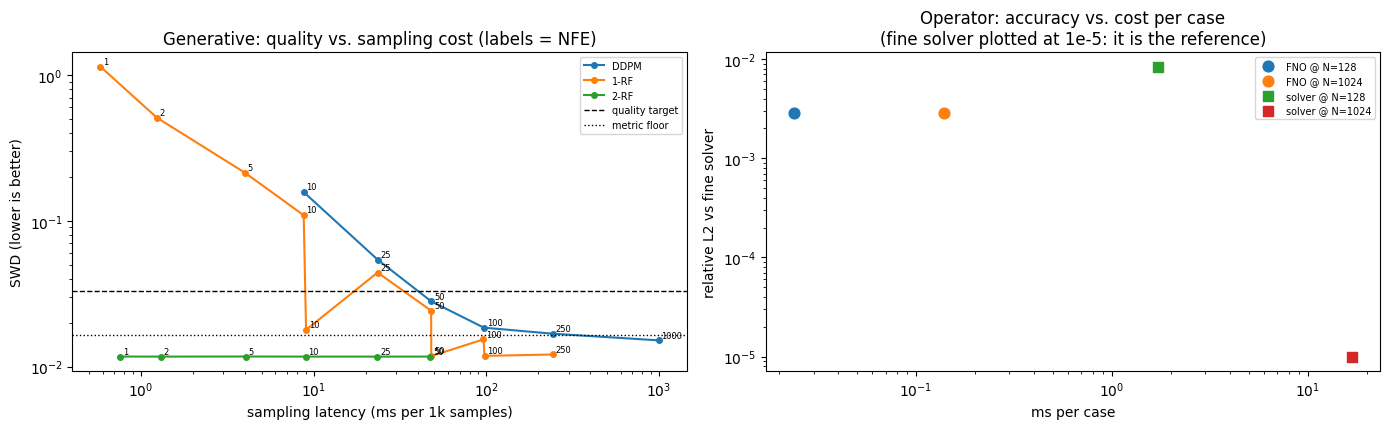

In [30]:
target, _ = report.quality_target(RESULTS)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

for name, rows in report.generative_rows(RESULTS).items():
    lat = [report._per_1k_ms(m, N_EVAL) for m in rows]
    ax[0].plot(lat, [m["swd"] for m in rows], "o-", ms=4, label=name)
    for m, l in zip(rows, lat):
        ax[0].annotate(str(m["nfe"]), (l, m["swd"]), fontsize=6, xytext=(2, 2), textcoords="offset points")
ax[0].axhline(target, color="k", ls="--", lw=1, label="quality target")
ax[0].axhline(FLOOR["swd"], color="k", ls=":", lw=1, label="metric floor")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("sampling latency (ms per 1k samples)"); ax[0].set_ylabel("SWD (lower is better)")
ax[0].set_title("Generative: quality vs. sampling cost (labels = NFE)"); ax[0].legend(fontsize=7)

op = report.operator_scorecard(RESULTS)
for k, c in op["methods"].items():
    ms = 1000 * c["seconds"] / RESULTS["meta"]["n_test_cases"]
    err = max(c["rel_l2"], 1e-5)               # fine solver is the reference (error 0)
    ax[1].scatter(ms, err, s=60, marker="o" if k.startswith("FNO") else "s", label=k)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("ms per case"); ax[1].set_ylabel("relative L2 vs fine solver")
ax[1].set_title("Operator: accuracy vs. cost per case\n(fine solver plotted at 1e-5: it is the reference)")
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### What must be checked before scaling

These are the conditions under which the toy results could fail to transfer. Each is phrased as a check with a pass/fail outcome.

In [31]:
PRE_SCALE_CHECKS = r'''
**Applies to every recipe**
1. **Seed variance.** Every number here is from a single seed. Repeat with at least 3 seeds and report mean ± spread. A difference smaller than the seed-to-seed spread doesn't count as a difference.
2. **Timing on the target hardware.** Colab GPUs are shared and timings are noisy. Re-measure latency, wall-clock and peak VRAM on the pilot GPU type, with repeats.
3. **Keep the guards on.** LR range test plus the constant-predictor abort (F2), schedule fingerprint plus terminal-SNR check (F1), and resolution-consistency gap (F3) run automatically on every new configuration.

**Operator pilot (FNO)**
4. **Real boundary conditions and geometry.** The FFT assumes a periodic domain; platform wave loading is not periodic. Verify accuracy with domain padding or a geometry-aware variant before trusting the speedup.
5. **Out-of-distribution inputs.** Training inputs came from one random-field family at one viscosity. Test storm-like extremes and shifted parameters, and agree an acceptance threshold on the engineering quantity (for example peak load), not on mean L2; compare the worst-case error in the scorecard with that threshold.
6. **Break-even on training data.** The surrogate needed 1000 solver runs to train. Compute queries-to-break-even = (data-generation + training cost) / (per-query saving) at pilot fidelity; the pilot only pays off above that query volume.
7. **Scaling with dimension.** Spectral weights grow with modes^d in 2D/3D. Measure parameters, VRAM and latency at the real grid size before committing cluster time.

**Generative recipe (if pursued)**
8. **Domain metrics.** SWD and MMD do not scale to high-dimensional fields, and F1 showed that coarse metrics can pass a broken model. Define physics-based checks: spectra, exceedance probabilities and extreme-value statistics.
9. **No hidden data assumptions.** DDPM's quality here relies on clipping to known data bounds; confirm the chosen recipe works without them on real fields.
10. **Reflow ceiling.** 2-RF can only be as good as the 1-RF that generated its pairs; confirm that the speed gain is worth any quality loss at pilot scale.
'''
display(Markdown(PRE_SCALE_CHECKS))


**Applies to every recipe**
1. **Seed variance.** Every number here is from a single seed. Repeat with at least 3 seeds and report mean ± spread. A difference smaller than the seed-to-seed spread doesn't count as a difference.
2. **Timing on the target hardware.** Colab GPUs are shared and timings are noisy. Re-measure latency, wall-clock and peak VRAM on the pilot GPU type, with repeats.
3. **Keep the guards on.** LR range test plus the constant-predictor abort (F2), schedule fingerprint plus terminal-SNR check (F1), and resolution-consistency gap (F3) run automatically on every new configuration.

**Operator pilot (FNO)**
4. **Real boundary conditions and geometry.** The FFT assumes a periodic domain; platform wave loading is not periodic. Verify accuracy with domain padding or a geometry-aware variant before trusting the speedup.
5. **Out-of-distribution inputs.** Training inputs came from one random-field family at one viscosity. Test storm-like extremes and shifted parameters, and agree an acceptance threshold on the engineering quantity (for example peak load), not on mean L2; compare the worst-case error in the scorecard with that threshold.
6. **Break-even on training data.** The surrogate needed 1000 solver runs to train. Compute queries-to-break-even = (data-generation + training cost) / (per-query saving) at pilot fidelity; the pilot only pays off above that query volume.
7. **Scaling with dimension.** Spectral weights grow with modes^d in 2D/3D. Measure parameters, VRAM and latency at the real grid size before committing cluster time.

**Generative recipe (if pursued)**
8. **Domain metrics.** SWD and MMD do not scale to high-dimensional fields, and F1 showed that coarse metrics can pass a broken model. Define physics-based checks: spectra, exceedance probabilities and extreme-value statistics.
9. **No hidden data assumptions.** DDPM's quality here relies on clipping to known data bounds; confirm the chosen recipe works without them on real fields.
10. **Reflow ceiling.** 2-RF can only be as good as the 1-RF that generated its pairs; confirm that the speed gain is worth any quality loss at pilot scale.


### The memo
Generated from the measured results and saved to `results/decision_memo.md`.

In [32]:
rec = report.recommend(RESULTS)
RESULTS["recommendation"] = {k: v for k, v in rec.items() if k not in ("generative_card", "operator_card")}
json.dump(RESULTS, open("results/results.json", "w"), indent=2, default=float)

memo = report.memo_md(RESULTS, PRE_SCALE_CHECKS)
Path("results/decision_memo.md").write_text(memo, encoding="utf-8")
display(Markdown(memo))

# Decision memo: generative and operator-learning pilot

**To:** Kwame Boateng · **Hardware measured on:** Tesla T4 · **Mode:** full budget

## Recommendation

**Pilot the Fourier Neural Operator.** On the Burgers benchmark its error against the fine solver is 0.28% relative L2, versus 0.84% for the cheap classical solver, while running **73x faster** than that solver and **709x faster** than the fine solver. It also passed the resolution-consistency guard, so one trained model serves every grid tested.

**Of the generative recipes, 2-RF is the one to carry forward.** It reaches the quality target with 1 network evaluations, 0.8 ms per 1k samples (others: DDPM: 47.9 ms at NFE 50; 1-RF: 9.0 ms at NFE 10). DDPM also depends on clipping to known data bounds, which real wave-load fields won't provide.

The operator is the stronger pilot candidate for Halden because it directly replaces a cost we already pay, solver runs, and we measured that saving against the solver itself. The generative models were measured only against each other on a 2D toy distribution. They tell us which recipe to prefer, not yet whether either one earns money.

## Measured basis

### Operator: FNO vs. the solver it would replace
| Method | Time for test set (s) | ms / case | Speedup vs fine solver | rel. L2 vs fine solver | Peak VRAM (MiB) |
|---|---|---|---|---|---|
| FNO @ N=128 | 0.0048 | 0.024 | 709x | 0.0028 | 83 |
| FNO @ N=1024 | 0.0279 | 0.140 | 121x | 0.0028 | 303 |
| solver @ N=128 | 0.3455 | 1.727 | 10x | 0.0084 | 54 |
| solver @ N=1024 | 3.3714 | 16.857 | 1x | 0.0000 | 70 |

FNO trained at N=128 in 114s; at N=1024: mean rel. L2 0.0028, 95th pct 0.0057, worst 0.0472; spread of mean error across N=32..1024: 0.0031.

### Generative: DDPM vs. rectified flow (same data, network, training budget)
Quality target: SWD <= 0.033 (2x the metric floor 0.016).

| Recipe | Train wall-clock (s) | Train peak VRAM (MiB) | Best SWD (support) @ NFE | NFE to hit target | Latency at target (ms / 1k samples) | Needs known data bounds |
|---|---|---|---|---|---|---|
| DDPM | 131 | 79 | 0.015 (0.984) @ 1000 | 50 | 47.9 | yes (x0 clipping) |
| 1-RF | 127 | 90 | 0.012 (0.970) @ 50 | 10 | 9.0 | no |
| 2-RF | 274 | 101 | 0.012 (0.972) @ 25 | 1 | 0.8 | no |

2-RF wall-clock includes training the 1-RF it distills from and generating its coupling pairs.

## Failure study

Three failures were induced, diagnosed and repaired. Each now has an automated guard (full log: `results/failure_log.md`):
- **F1 (DDPM): Mismatched noise schedule (train linear, sample cosine).** Guard: checkpoint stores schedule_fingerprint (sha1 of betas); ddpm.check_schedule raises on mismatch and on abar_T > 1e-3. Report SWD/MMD, not support fraction alone.
- **F2 (Rectified flow (1-RF)): Exploding learning rate.** Guard: LR range test before each new scale/architecture; abort a run whose loss stays within 5% of the closed-form constant-predictor loss; log parameter norm (87x baseline here) as a second alarm. Don't count on clipping with Adam.
- **F3 (FNO-1d): Resolution mismatch between training and evaluation grids.** Guard: resolution_consistency(model, u0_fine, coarse) < 1e-2 at every deployment grid, checked in CI; always report error at more than one grid.

## What must be checked before scaling


**Applies to every recipe**
1. **Seed variance.** Every number here is from a single seed. Repeat with at least 3 seeds and report mean ± spread. A difference smaller than the seed-to-seed spread doesn't count as a difference.
2. **Timing on the target hardware.** Colab GPUs are shared and timings are noisy. Re-measure latency, wall-clock and peak VRAM on the pilot GPU type, with repeats.
3. **Keep the guards on.** LR range test plus the constant-predictor abort (F2), schedule fingerprint plus terminal-SNR check (F1), and resolution-consistency gap (F3) run automatically on every new configuration.

**Operator pilot (FNO)**
4. **Real boundary conditions and geometry.** The FFT assumes a periodic domain; platform wave loading is not periodic. Verify accuracy with domain padding or a geometry-aware variant before trusting the speedup.
5. **Out-of-distribution inputs.** Training inputs came from one random-field family at one viscosity. Test storm-like extremes and shifted parameters, and agree an acceptance threshold on the engineering quantity (for example peak load), not on mean L2; compare the worst-case error in the scorecard with that threshold.
6. **Break-even on training data.** The surrogate needed 1000 solver runs to train. Compute queries-to-break-even = (data-generation + training cost) / (per-query saving) at pilot fidelity; the pilot only pays off above that query volume.
7. **Scaling with dimension.** Spectral weights grow with modes^d in 2D/3D. Measure parameters, VRAM and latency at the real grid size before committing cluster time.

**Generative recipe (if pursued)**
8. **Domain metrics.** SWD and MMD do not scale to high-dimensional fields, and F1 showed that coarse metrics can pass a broken model. Define physics-based checks: spectra, exceedance probabilities and extreme-value statistics.
9. **No hidden data assumptions.** DDPM's quality here relies on clipping to known data bounds; confirm the chosen recipe works without them on real fields.
10. **Reflow ceiling.** 2-RF can only be as good as the 1-RF that generated its pairs; confirm that the speed gain is worth any quality loss at pilot scale.



In [33]:
!git add .

In [36]:
!git config --global user.email "milleson@csp.edu"
!git config --global user.name "Nick Milleson"
!git commit -m 'final run'

[main 1d04a02] final run
 4 files changed, 364 insertions(+), 366 deletions(-)


In [38]:
!

checkpoints  data  halden  halden_scouting.ipynb  requirements.txt  results
